# Dyck-(2,5) CFG next-token results and probes

This notebook is copied from the Dyck-(2,3) CFG next-token notebook, but changes the bounded CFG depth to 5 while keeping two bracket types. It trains or loads only the `len_80_120` Dyck-(2,5) runs, then inspects the same probe layout: fixed-prefix sufficient-statistic probes, stack/top-of-stack probes, PCA views, supervised projection views, prefix sweeps, and direction arithmetic. The saved artifacts are isolated under `results/dyck25_cfg_next_token_len_80_120`.

In [16]:
from pathlib import Path
import json
import sys

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

try:
    from sklearn.decomposition import PCA
except Exception:
    PCA = None

from hse.analysis.probes.linear import extract_linear_weight, fit_logistic_probe, fit_ridge_probe
from hse.experiments.dyck23 import DYCK23_LENGTH_BINS, DYCK23_MODEL_SPECS, run_dyck23_suite
from hse.tasks.dyck23 import Dyck23Config, Dyck23Sampler, validate_dyck23_tokens
from hse.utils.labels_io import load_labels


In [17]:
EXPERIMENT_NAME = 'dyck25_cfg_next_token_len_80_120'
RESULTS_ROOT = ROOT / 'results' / EXPERIMENT_NAME
FIGURES_ROOT = RESULTS_ROOT / 'figures'
FIGURES_ROOT.mkdir(parents=True, exist_ok=True)

MODEL_TYPES = ['rnn', 'lstm', 'transformer', 'mamba']
SEED = 0
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

RUN_TRAINING = False  # Set True only to intentionally train all 4 Dyck(2,5) runs.
ALLOW_OVERWRITE = False  # Keep False so existing Dyck(2,5) artifacts fail fast instead of being rewritten.
TRAIN_EXAMPLES = 10_000
TEST_EXAMPLES = 2_000
PROBE_EXAMPLES = 1_024
TRAINING_STEPS = 15_000
EPOCHS = 20
BATCH_SIZE = 128
MAX_PROBE_ROWS = 20_000

MAX_DEPTH = 5
DYCK25_LENGTH_BINS = {
    'len_80_120': {'min_length': 80, 'max_length': 120, 'max_depth': MAX_DEPTH},
}
# Keep the original variable name so the copied analysis cells can stay unchanged.
DYCK23_LENGTH_BINS = DYCK25_LENGTH_BINS

BALANCE_PROBE_BY = 'depth_top_class'
PROBE_MIN_CLASS_COUNT = 8
PROBE_MAX_PER_CLASS = 128
PCA_MAX_POINTS = 5_000

RIDGE_TARGETS = [
    'left', 'right', 'height',
    'left_round', 'right_round', 'height_round',
    'left_square', 'right_square', 'height_square',
]
CLASS_TARGETS = ['top_type_class', 'depth_top_class', 'legal_next_class', 'height_class']
COUNTER_TARGET_PAIRS = [
    ('height_round', 'height_square'),
    ('left_round', 'left_square'),
    ('right_round', 'right_square'),
]
GRID_TARGET_PAIRS = [
    ('height_round', 'height_square'),
    ('left_round', 'left_square'),
]
COUNTER_TOTAL_TARGETS = {
    ('height_round', 'height_square'): 'height',
    ('left_round', 'left_square'): 'left',
    ('right_round', 'right_square'): 'right',
}


FIXED_PREFIX_BY_BIN = {
    'len_80_120': 100,
}
SWEEP_PREFIX_BY_BIN = {
    'len_80_120': list(range(84, 121, 4)),
}

pd.DataFrame([
    {'model': name, **{k: v for k, v in spec.items() if k != 'state_kind'}}
    for name, spec in DYCK23_MODEL_SPECS.items()
])


,model,layers,emb_dim,hidden_dim,dropout,learned_initial_state,fused,n_heads,ffn_dim,pos_encoding,embed_scale,final_layer_norm,state_dim,expansion_factor,require_official_mamba
0,rnn,5,80,80,0.1,True,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,lstm,5,40,40,0.1,True,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,transformer,5,32,32,0.1,NaN,NaN,8.0,128.0,sinusoidal,True,True,NaN,NaN,NaN
3,mamba,5,36,36,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.0,2.0,True


全局设置现在固定在 Dyck(2,5) 的 `len_80_120` 桶：两个 bracket 类型，最大总深度 5，所以合法 `(height_round, height_square)` 状态是三角形里的 21 个格点。`RUN_TRAINING=False` 时只读取已有结果；`ALLOW_OVERWRITE=False` 会阻止误覆盖已经训练好的 Dyck(2,5) artifacts。

## 1. Load or train the 4 Dyck-(2,5) runs

Artifacts for this notebook live under `results/dyck25_cfg_next_token_len_80_120`. This cell only reads those artifacts unless `RUN_TRAINING` is explicitly set to `True`; with `ALLOW_OVERWRITE = False`, it refuses to train if the expected summaries or run directories already exist.

In [18]:
runs_path = RESULTS_ROOT / 'runs.csv'
probe_path = RESULTS_ROOT / 'probe_summary.csv'
planned_run_dirs = [
    RESULTS_ROOT / length_bin / f'{model_type}_seed{SEED}'
    for length_bin in DYCK23_LENGTH_BINS
    for model_type in MODEL_TYPES
]
existing_artifacts = [
    path for path in [runs_path, probe_path, *planned_run_dirs]
    if path.exists()
]

if RUN_TRAINING and existing_artifacts and not ALLOW_OVERWRITE:
    raise FileExistsError(
        'Refusing to overwrite existing Dyck(2,5) artifacts. '
        f'Found {len(existing_artifacts)} existing path(s) under {RESULTS_ROOT}. '
        'Change EXPERIMENT_NAME, or set ALLOW_OVERWRITE = True only if overwriting is intentional. '
        f'First existing path: {existing_artifacts[0]}'
    )

if RUN_TRAINING:
    runs_df, probe_df = run_dyck23_suite(
        seed=SEED,
        models=MODEL_TYPES,
        length_bins=DYCK23_LENGTH_BINS,
        train_examples=TRAIN_EXAMPLES,
        test_examples=TEST_EXAMPLES,
        probe_examples=PROBE_EXAMPLES,
        steps=TRAINING_STEPS,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        max_probe_rows=MAX_PROBE_ROWS,
        device=DEVICE,
        results_root=RESULTS_ROOT,
        setting_name=EXPERIMENT_NAME,
    )
else:
    if not runs_path.exists() or not probe_path.exists():
        raise FileNotFoundError(
            f'Missing {runs_path} or {probe_path}. Set RUN_TRAINING = True only if you need to regenerate them.'
        )
    runs_df = pd.read_csv(runs_path)
    probe_df = pd.read_csv(probe_path)

expected_runs = len(MODEL_TYPES) * len(DYCK23_LENGTH_BINS)

if len(runs_df) != expected_runs or len(probe_df) != expected_runs:
    if (runs_path.exists() or probe_path.exists()) and not ALLOW_OVERWRITE:
        raise FileExistsError(
            'Summary CSVs have unexpected row counts, and ALLOW_OVERWRITE is False. '
            'Use a new EXPERIMENT_NAME or set ALLOW_OVERWRITE = True only if rewriting summaries is intentional.'
        )
    run_rows = []
    probe_rows = []
    for length_bin in DYCK23_LENGTH_BINS:
        for model_type in MODEL_TYPES:
            run_dir = RESULTS_ROOT / length_bin / f'{model_type}_seed{SEED}'
            config_path = run_dir / 'config.json'
            metrics_path = run_dir / 'metrics.json'
            if not config_path.exists() or not metrics_path.exists():
                raise FileNotFoundError(f'Missing completed artifacts under {run_dir}')
            config = json.load(open(config_path))
            metrics = json.load(open(metrics_path))
            labels_path = run_dir / 'labels.parquet'
            if labels_path.exists():
                hidden_rows = len(pd.read_parquet(labels_path, columns=['example_id']))
            else:
                hidden_rows = len(pd.read_csv(run_dir / 'labels.csv', usecols=['example_id']))
            eval_metrics = metrics['eval']
            hidden_dim = int(config['model'].get('hidden_dim', config['model'].get('emb_dim')))
            run_rows.append({
                'length_bin': length_bin,
                'model': model_type,
                'seed': config['seed'],
                'run_dir': str(run_dir.resolve()),
                'loss': eval_metrics['loss'],
                'accuracy': eval_metrics['accuracy'],
                'dyck_accuracy': eval_metrics['dyck_accuracy'],
                'hidden_rows': hidden_rows,
                'hidden_dim': hidden_dim,
                'params': config['trainable_parameters'],
                'backbone_params': config['backbone_parameters_excluding_lm_head'],
                'elapsed_seconds': metrics.get('elapsed_seconds'),
            })
            probe_rows.append({
                'length_bin': length_bin,
                'model': model_type,
                'seed': config['seed'],
                **metrics.get('probe', {}),
                **metrics.get('compression', {}),
            })
    runs_df = pd.DataFrame(run_rows)
    probe_df = pd.DataFrame(probe_rows)
    runs_df.to_csv(runs_path, index=False)
    probe_df.to_csv(probe_path, index=False)

if len(runs_df) != expected_runs or len(probe_df) != expected_runs:
    raise ValueError(f'Expected {expected_runs} runs/probe rows, got {len(runs_df)} and {len(probe_df)}.')

runs_df.sort_values(['length_bin', 'model']).reset_index(drop=True)


,length_bin,model,seed,run_dir,loss,accuracy,dyck_accuracy,hidden_rows,hidden_dim,params,backbone_params,elapsed_seconds
0,len_80_120,lstm,0,/home/hp_twist_shan/Research/Hidden State Eval...,0.936215,0.535518,0.532867,103258,40,66367,66080,154.622262
1,len_80_120,mamba,0,/home/hp_twist_shan/Research/Hidden State Eval...,0.945154,0.533559,0.532398,103258,36,61351,61092,392.401461
2,len_80_120,rnn,0,/home/hp_twist_shan/Research/Hidden State Eval...,0.937622,0.538434,0.536515,103258,80,66327,65760,131.223827
3,len_80_120,transformer,0,/home/hp_twist_shan/Research/Hidden State Eval...,0.937834,0.536737,0.533106,103258,32,64039,63808,1021.614149


### 结果分析（Dyck(2,5), len_80_120）

这 4 个模型都已经跑完。next-token exact accuracy 都在一个很窄的区间里：RNN 0.5384，Transformer 0.5367，LSTM 0.5355，Mamba 0.5336；`dyck_accuracy` 也几乎一样，在 0.5324-0.5365。也就是说低 accuracy 不是 EOS 或 padding 造成的，而是 Dyck CFG 的 next-token 监督本身有分支不确定性：模型可能已经知道当前 stack state，但单步预测某一个采样出来的合法括号仍然不容易。

训练开销差别更明显：RNN/LSTM 大约 131s/155s，Mamba 392s，Transformer 1022s。后面的 probe 比 raw next-token accuracy 更能说明模型是否学到了 Dyck(2,5) 的状态表示。

## 2. Load saved probe arrays

The suite saves one row per valid next-token prediction position. For a fixed-prefix view, filter by `dyck_seen`, then balance by `depth_top_class` as in the Dyck-k long notebook.

In [19]:
def load_run_arrays(run_dir):
    run_dir = Path(run_dir)
    if not run_dir.is_absolute():
        candidates = [ROOT / run_dir, RESULTS_ROOT / run_dir]
        run_dir = next((path for path in candidates if (path / 'hidden_states.pt').exists()), ROOT / run_dir)
    hidden_path = run_dir / 'hidden_states.pt'
    if not hidden_path.exists():
        raise FileNotFoundError(f'Missing hidden states at {hidden_path}')
    hidden = torch.load(hidden_path, map_location='cpu').numpy()
    labels_path = run_dir / 'labels.parquet'
    if not labels_path.exists():
        labels_path = run_dir / 'labels.csv'
    labels = load_labels(labels_path)
    return {'X': hidden, 'labels': labels, 'run_dir': run_dir}


def select_prefix(data, prefix):
    labels = data['labels']
    mask = labels['dyck_seen'].to_numpy() == int(prefix)
    return {'X': data['X'][mask], 'labels': labels.loc[mask].reset_index(drop=True), 'run_dir': data['run_dir']}


def balance_data_by_label(data, label=BALANCE_PROBE_BY, seed=0, max_per_class=PROBE_MAX_PER_CLASS, min_per_class=PROBE_MIN_CLASS_COUNT):
    labels = data['labels']
    rng = np.random.default_rng(seed)
    chosen = []
    for _, idx in labels.groupby(label).indices.items():
        idx = np.asarray(idx)
        if len(idx) < min_per_class:
            continue
        take = min(len(idx), max_per_class) if max_per_class else len(idx)
        chosen.append(rng.choice(idx, size=take, replace=False))
    if not chosen:
        return data
    chosen = np.sort(np.concatenate(chosen))
    return {'X': data['X'][chosen], 'labels': labels.iloc[chosen].reset_index(drop=True), 'run_dir': data['run_dir']}


def print_class_balance(data, label=BALANCE_PROBE_BY, name='data', limit=12):
    counts = data['labels'][label].value_counts().sort_index()
    preview = ', '.join(f'{k}:{v}' for k, v in counts.head(limit).items())
    print(f'{name} {label} counts -> {preview}')


run_arrays = {
    (row.length_bin, row.model): load_run_arrays(row.run_dir)
    for row in runs_df.itertuples()
}


In [20]:
def _split_indices(n, seed=0, test_size=0.25):
    rng = np.random.default_rng(seed)
    idx = rng.permutation(n)
    n_test = max(1, int(round(n * test_size)))
    return idx[n_test:], idx[:n_test]


def _standardize_train_test(X_train, X_test):
    mean = X_train.mean(axis=0, keepdims=True)
    std = X_train.std(axis=0, keepdims=True)
    std[std < 1e-8] = 1.0
    return (X_train - mean) / std, (X_test - mean) / std, mean, std


def _r2_score_np(y_true, y_pred):
    ss_res = float(((y_true - y_pred) ** 2).sum())
    ss_tot = float(((y_true - y_true.mean()) ** 2).sum())
    return 1.0 - ss_res / (ss_tot + 1e-12)


def fit_ridge_train_test(X_train, y_train, X_test, y_test, name, alpha=1.0):
    X_train = np.asarray(X_train, dtype=np.float64)
    X_test = np.asarray(X_test, dtype=np.float64)
    y_train = np.asarray(y_train, dtype=np.float64)
    y_test = np.asarray(y_test, dtype=np.float64)
    X_train_s, X_test_s, mean, std = _standardize_train_test(X_train, X_test)
    X_aug = np.concatenate([X_train_s, np.ones((len(X_train_s), 1))], axis=1)
    eye = np.eye(X_aug.shape[1])
    eye[-1, -1] = 0.0
    system = X_aug.T @ X_aug + alpha * eye
    rhs = X_aug.T @ y_train
    try:
        coef_aug = np.linalg.solve(system, rhs)
    except np.linalg.LinAlgError:
        coef_aug = np.linalg.pinv(system) @ rhs
    pred = np.concatenate([X_test_s, np.ones((len(X_test_s), 1))], axis=1) @ coef_aug
    coef = coef_aug[:-1] / std.squeeze()
    intercept = float(coef_aug[-1] - (mean.squeeze() / std.squeeze()) @ coef_aug[:-1])
    return {'name': name, 'probe': {'coef': coef, 'intercept': intercept}, 'r2': float(_r2_score_np(y_test, pred)), 'mae': float(np.abs(y_test - pred).mean())}


def _shared_class_subset(X_train, y_train, X_test, y_test, min_count=2):
    train_counts = pd.Series(y_train).value_counts()
    test_counts = pd.Series(y_test).value_counts()
    keep = np.intersect1d(
        train_counts[train_counts >= min_count].index.to_numpy(),
        test_counts[test_counts >= min_count].index.to_numpy(),
    )
    train_mask = np.isin(y_train, keep)
    test_mask = np.isin(y_test, keep)
    return X_train[train_mask], y_train[train_mask], X_test[test_mask], y_test[test_mask]


def fit_logistic_train_test(X_train, y_train, X_test, y_test, name):
    X_train = np.asarray(X_train, dtype=np.float32)
    X_test = np.asarray(X_test, dtype=np.float32)
    y_train = np.asarray(y_train)
    y_test = np.asarray(y_test)
    X_train, y_train, X_test, y_test = _shared_class_subset(X_train, y_train, X_test, y_test)
    classes = np.unique(y_train)
    if len(classes) < 2 or len(X_test) == 0:
        return {'name': name, 'probe': None, 'accuracy': float('nan'), 'n_classes': int(len(classes))}
    class_to_idx = {cls: idx for idx, cls in enumerate(classes)}
    y_train_idx = np.array([class_to_idx[v] for v in y_train], dtype=np.int64)
    y_test_idx = np.array([class_to_idx[v] for v in y_test], dtype=np.int64)
    X_train_s, X_test_s, _, std = _standardize_train_test(X_train, X_test)
    model = torch.nn.Linear(X_train_s.shape[1], len(classes))
    opt = torch.optim.LBFGS(model.parameters(), lr=0.5, max_iter=100)
    loss_fn = torch.nn.CrossEntropyLoss()
    X_train_t = torch.tensor(X_train_s, dtype=torch.float32)
    y_train_t = torch.tensor(y_train_idx, dtype=torch.long)

    def closure():
        opt.zero_grad()
        loss = loss_fn(model(X_train_t), y_train_t)
        loss.backward()
        return loss

    opt.step(closure)
    with torch.no_grad():
        pred = model(torch.tensor(X_test_s, dtype=torch.float32)).argmax(dim=-1).numpy()
    coef = model.weight.detach().numpy() / std.squeeze()[None, :]
    return {'name': name, 'probe': {'coef': coef, 'classes': classes}, 'accuracy': float((pred == y_test_idx).mean()), 'n_classes': int(len(classes))}


def run_stack_probes(data, seed=0):
    X = data['X']
    labels = data['labels']
    train_idx, test_idx = _split_indices(len(labels), seed=seed)
    fitted = {}
    rows = []

    for target in RIDGE_TARGETS:
        if target not in labels:
            continue
        result = fit_ridge_train_test(X[train_idx], labels[target].to_numpy()[train_idx], X[test_idx], labels[target].to_numpy()[test_idx], target)
        fitted[f'ridge_{target}'] = result
        rows.append({'probe_type': 'ridge', 'target': target, 'r2': result['r2'], 'mae': result['mae']})

    for target in CLASS_TARGETS:
        if target not in labels or labels[target].nunique() <= 1:
            continue
        y = labels[target].to_numpy()
        result = fit_logistic_train_test(X[train_idx], y[train_idx], X[test_idx], y[test_idx], target)
        fitted[f'logistic_{target}'] = result
        rows.append({'probe_type': 'logistic', 'target': target, 'accuracy': result['accuracy'], 'n_classes': labels[target].nunique()})
    return fitted, pd.DataFrame(rows)


fixed_probe_results = {}
fixed_probe_rows = []
for length_bin in DYCK23_LENGTH_BINS:
    prefix = FIXED_PREFIX_BY_BIN[length_bin]
    for model_type in MODEL_TYPES:
        raw = select_prefix(run_arrays[(length_bin, model_type)], prefix)
        balanced = balance_data_by_label(raw, seed=SEED)
        print_class_balance(balanced, name=f'{length_bin} {model_type} prefix={prefix}')
        fitted, table = run_stack_probes(balanced, seed=SEED)
        fixed_probe_results[(length_bin, model_type)] = {'data': balanced, 'fitted': fitted, 'table': table, 'prefix': prefix}
        for row in table.to_dict('records'):
            fixed_probe_rows.append({'length_bin': length_bin, 'model': model_type, 'prefix': prefix, **row})

fixed_probe_df = pd.DataFrame(fixed_probe_rows)
fixed_probe_df.to_csv(RESULTS_ROOT / 'fixed_prefix_probe_summary.csv', index=False)
fixed_probe_df


len_80_120 rnn prefix=100 depth_top_class counts -> 0:108, 7:128, 8:128, 13:66, 14:71
len_80_120 lstm prefix=100 depth_top_class counts -> 0:108, 7:128, 8:128, 13:66, 14:71
len_80_120 transformer prefix=100 depth_top_class counts -> 0:108, 7:128, 8:128, 13:66, 14:71
len_80_120 mamba prefix=100 depth_top_class counts -> 0:108, 7:128, 8:128, 13:66, 14:71


,length_bin,model,prefix,probe_type,target,r2,mae,accuracy,n_classes
0,len_80_120,rnn,100,ridge,left,0.986829,0.029115,NaN,NaN
1,len_80_120,rnn,100,ridge,right,0.986829,0.029115,NaN,NaN
2,len_80_120,rnn,100,ridge,height,0.986829,0.058230,NaN,NaN
3,len_80_120,rnn,100,ridge,left_round,-0.029751,2.707991,NaN,NaN
4,len_80_120,rnn,100,ridge,right_round,-0.034482,2.656829,NaN,NaN
5,len_80_120,rnn,100,ridge,height_round,0.121481,0.430814,NaN,NaN
6,len_80_120,rnn,100,ridge,left_square,-0.034306,2.716818,NaN,NaN
7,len_80_120,rnn,100,ridge,right_square,-0.033879,2.662092,NaN,NaN
8,len_80_120,rnn,100,ridge,height_square,0.026519,0.452825,NaN,NaN
9,len_80_120,rnn,100,logistic,top_type_class,NaN,NaN,1.000,3.0


### 结果分析（fixed prefix = 100）

固定在 prefix 100 时，总量状态非常可读：`height_r2` 分别是 LSTM 0.9965、RNN 0.9868、Transformer 0.9745、Mamba 0.9518，`height_class_accuracy` 基本为 1。栈顶相关分类也很强：RNN/LSTM/Transformer 的 `top_type_class` 和 `depth_top_class` 都接近或等于 1，Mamba 稍弱但仍有 `top_type_class=0.984`、`depth_top_class=0.984`。

区别主要在 per-type counter。Transformer 在 `height_round/height_square` 上最清楚（0.9690/0.9504）；Mamba 和 LSTM 是中等强度（Mamba 0.8132/0.8235，LSTM 0.7539/0.7889）。RNN 在这个固定 prefix 上 per-type height 很弱（0.1215/0.0265），但这不是“不会数”，因为它的总 height 很强，并且 prefix sweep / all-prefix 里 per-type 信息会恢复一些。更合理的解释是：在固定 prefix=100 且最大深度 5 的窄切片里，round/square 两类高度受到强 trade-off 约束，RNN 把状态压成更接近 total-depth 的表示。

`legal_next_class_accuracy` 只有 0.760-0.816，比 depth/top 低一截，说明“当前栈是什么”比“下一步完整合法动作集合是什么”更容易线性读出；后者还受剩余长度和终止条件影响。

## 3. PCA views and same-counter stack slices

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck25_cfg_next_token_len_80_120/figures/pca/len_80_120_rnn_pca.png


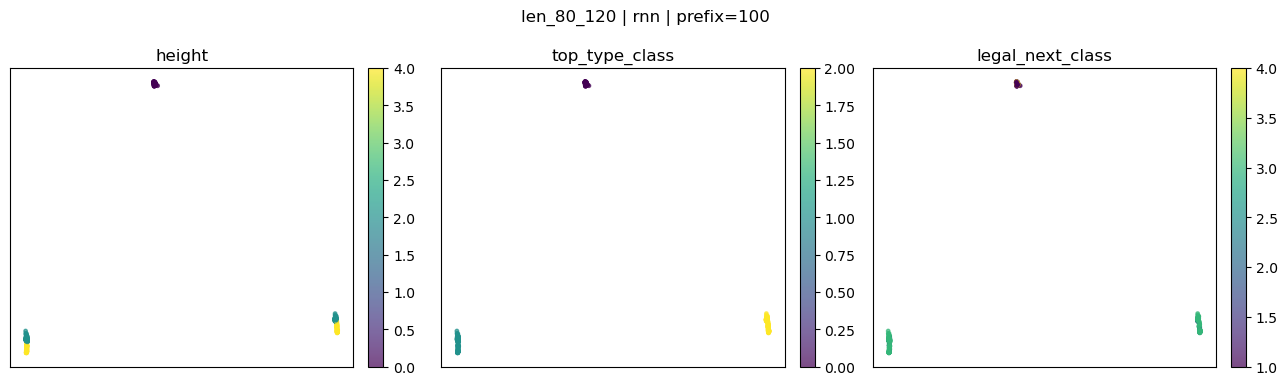

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck25_cfg_next_token_len_80_120/figures/stack_slices/len_80_120_rnn_same_counters_diff_stack.png


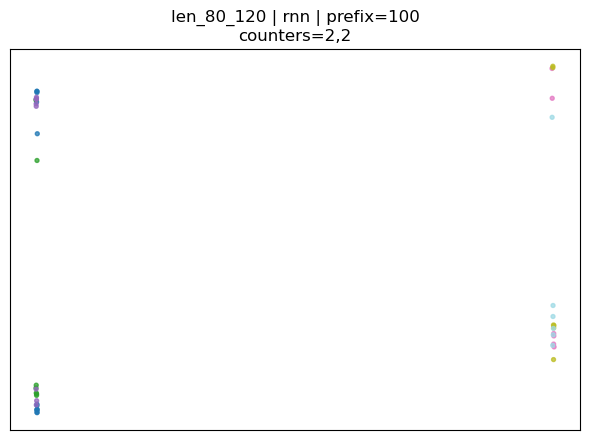

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck25_cfg_next_token_len_80_120/figures/pca/len_80_120_lstm_pca.png


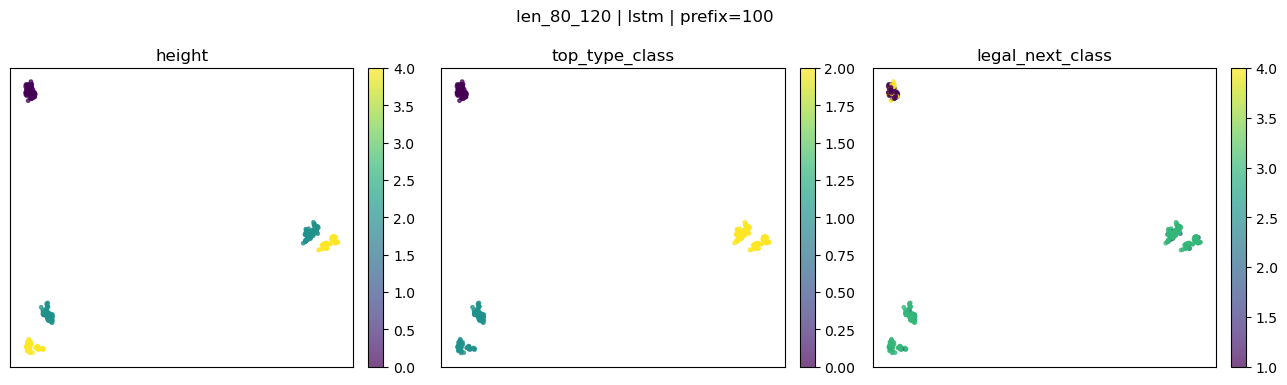

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck25_cfg_next_token_len_80_120/figures/stack_slices/len_80_120_lstm_same_counters_diff_stack.png


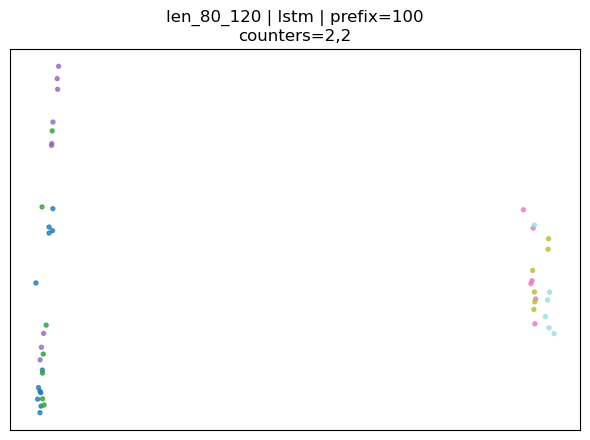

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck25_cfg_next_token_len_80_120/figures/pca/len_80_120_transformer_pca.png


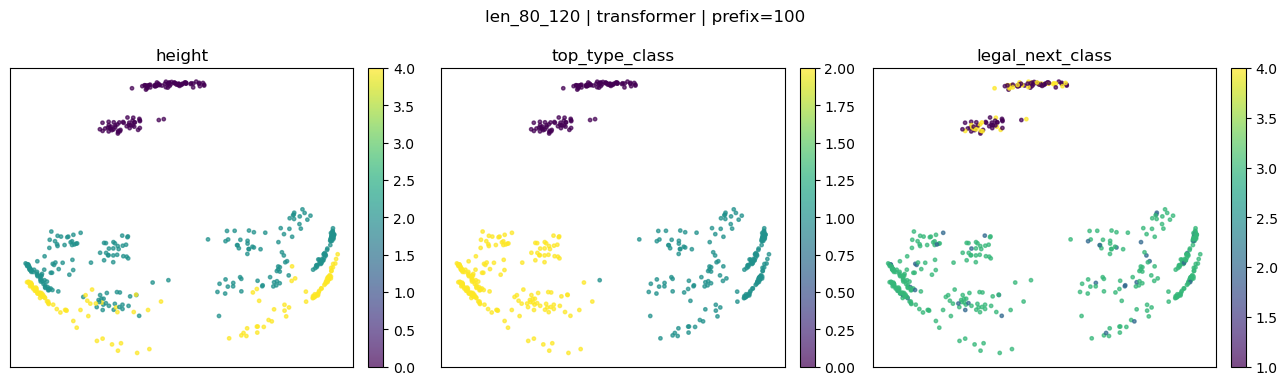

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck25_cfg_next_token_len_80_120/figures/stack_slices/len_80_120_transformer_same_counters_diff_stack.png


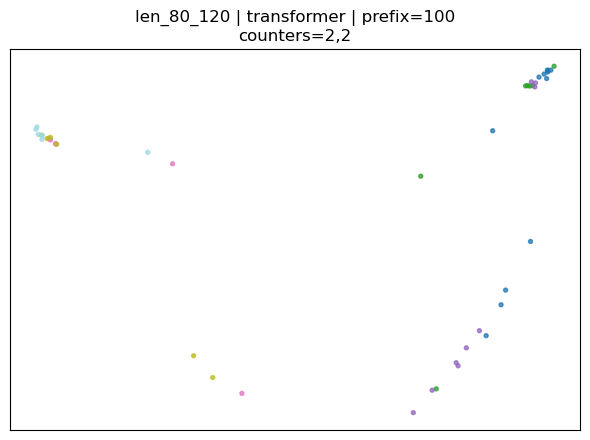

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck25_cfg_next_token_len_80_120/figures/pca/len_80_120_mamba_pca.png


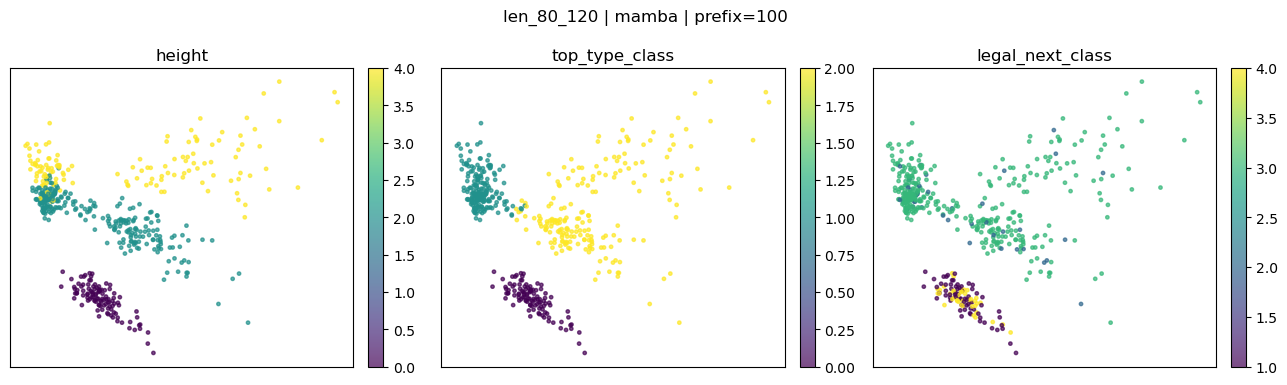

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck25_cfg_next_token_len_80_120/figures/stack_slices/len_80_120_mamba_same_counters_diff_stack.png


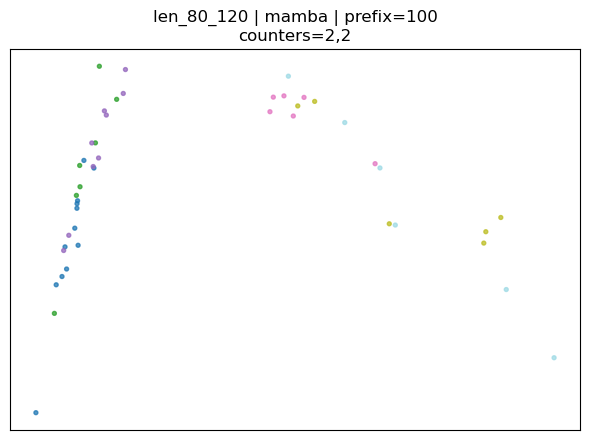

In [21]:
def pca_2d(X):
    X = np.asarray(X, dtype=np.float64)
    X = X - X.mean(axis=0, keepdims=True)
    if PCA is not None:
        return PCA(n_components=2).fit_transform(X)
    _, _, vt = np.linalg.svd(X, full_matrices=False)
    return X @ vt[:2].T


def finalize_figure(fig, section, stem):
    out_dir = FIGURES_ROOT / section
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / f'{stem}.png'
    fig.tight_layout()
    fig.savefig(out_path, dpi=150, bbox_inches='tight')
    print(f'saved figure -> {out_path}')


def plot_depth_counter_pca_panels(result, title, save_stem, max_points=PCA_MAX_POINTS):
    data = result['data']
    labels = data['labels']
    X = data['X']
    if len(labels) > max_points:
        idx = np.random.default_rng(SEED).choice(len(labels), size=max_points, replace=False)
        X = X[idx]
        labels = labels.iloc[idx].reset_index(drop=True)
    Z = pca_2d(X)
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
    for ax, target in zip(axes, ['height', 'top_type_class', 'legal_next_class']):
        vals = labels[target].to_numpy()
        sc = ax.scatter(Z[:, 0], Z[:, 1], c=vals, s=6, cmap='viridis', alpha=0.7)
        ax.set_title(target)
        ax.set_xticks([])
        ax.set_yticks([])
        fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
    fig.suptitle(title)
    finalize_figure(fig, 'pca', save_stem)
    plt.show()


def plot_same_counters_diff_stack(result, title, save_stem, max_points_per_stack=200):
    data = result['data']
    labels = data['labels'].copy()
    labels['counter_pair'] = labels['height_round'].astype(str) + ',' + labels['height_square'].astype(str)
    candidates = []
    for counter_pair, group in labels.groupby('counter_pair'):
        if group['stack_repr'].nunique() >= 2 and len(group) >= 20:
            candidates.append((counter_pair, len(group), group['stack_repr'].nunique()))
    if not candidates:
        print('no same-counter/different-stack slice found')
        return
    counter_pair = sorted(candidates, key=lambda x: (x[2], x[1]), reverse=True)[0][0]
    group = labels.loc[labels['counter_pair'] == counter_pair]
    idx = []
    rng = np.random.default_rng(SEED)
    for _, rows in group.groupby('stack_repr'):
        rows_idx = rows.index.to_numpy()
        take = min(len(rows_idx), max_points_per_stack)
        idx.append(rng.choice(rows_idx, size=take, replace=False))
    idx = np.concatenate(idx)
    X = data['X'][idx]
    sub = labels.loc[idx].reset_index(drop=True)
    Z = pca_2d(X)
    codes, names = pd.factorize(sub['stack_repr'])
    fig, ax = plt.subplots(figsize=(6, 4.5))
    sc = ax.scatter(Z[:, 0], Z[:, 1], c=codes, s=8, cmap='tab20', alpha=0.75)
    ax.set_title(f'{title}\ncounters={counter_pair}')
    ax.set_xticks([])
    ax.set_yticks([])
    finalize_figure(fig, 'stack_slices', save_stem)
    plt.show()


for length_bin in DYCK23_LENGTH_BINS:
    for model_type in MODEL_TYPES:
        result = fixed_probe_results[(length_bin, model_type)]
        title = f'{length_bin} | {model_type} | prefix={result["prefix"]}'
        plot_depth_counter_pca_panels(result, title, f'{length_bin}_{model_type}_pca')
        plot_same_counters_diff_stack(result, title, f'{length_bin}_{model_type}_same_counters_diff_stack')


`figures/pca/` 是 PCA sanity check，`figures/stack_slices/` 是 same-counter / different-stack slice。这里 Dyck(2,5) 的状态空间比 Dyck(2,3) 大：最大总深度从 3 变成 5，合法 counter lattice 从 10 个格点变成 21 个格点。

PCA 图主要看粗结构：depth、top type、legal-next 是否沿不同方向分开。same-counter slice 固定 `height_round = 1, height_square = 1`，也就是总 depth=2 且两个 bracket 类型各有一个未闭合；如果不同 stack order 仍能分开，说明 hidden state 不只是记两个 counter，还保留了栈顺序信息。

这版结果里，RNN 的 top/depth probe 很强，但 all-prefix counter lattice 呈现更多斜向 band；Transformer 的 per-type counter grid 最贴近整数格点。PCA/stack slice 可以作为几何直觉，定量结论以后面的 probe 和 lattice summary 为准。

## 4. Supervised directions and direction heatmaps

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck25_cfg_next_token_len_80_120/figures/directions/len_80_120_rnn_direction_heatmap.png


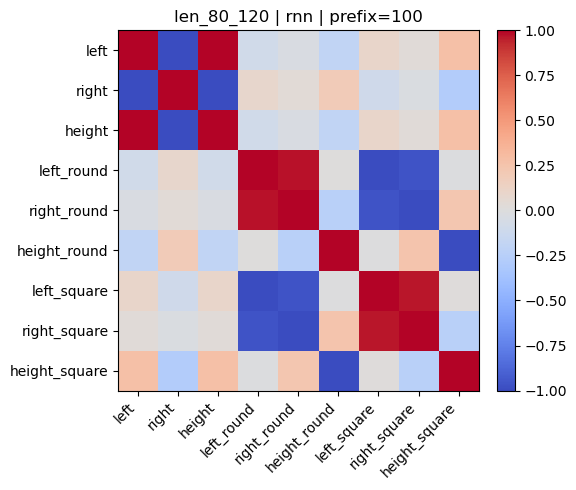

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck25_cfg_next_token_len_80_120/figures/supervised_projection/len_80_120_rnn_height_projection.png


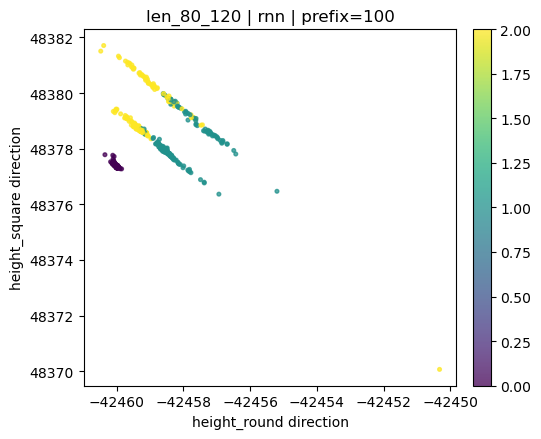

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck25_cfg_next_token_len_80_120/figures/directions/len_80_120_lstm_direction_heatmap.png


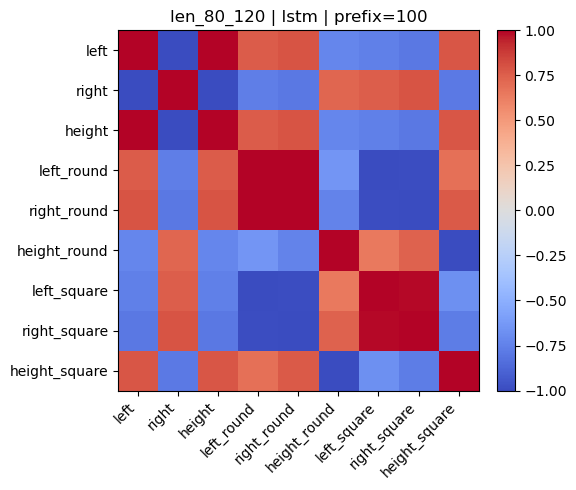

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck25_cfg_next_token_len_80_120/figures/supervised_projection/len_80_120_lstm_height_projection.png


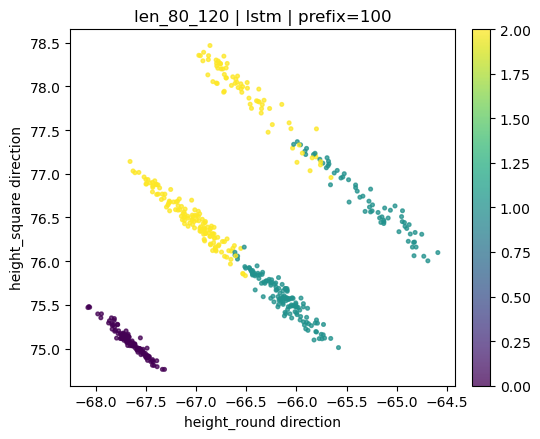

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck25_cfg_next_token_len_80_120/figures/directions/len_80_120_transformer_direction_heatmap.png


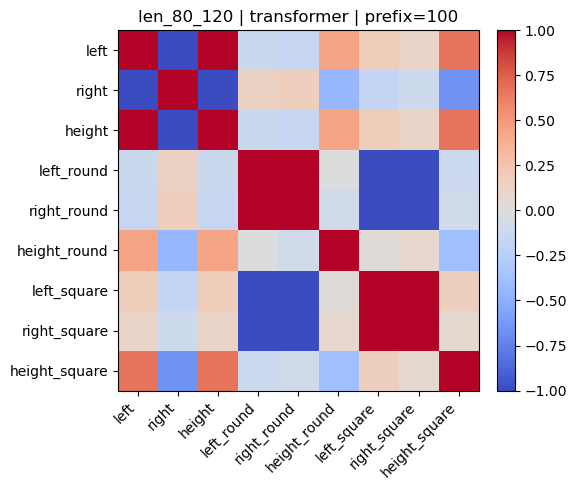

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck25_cfg_next_token_len_80_120/figures/supervised_projection/len_80_120_transformer_height_projection.png


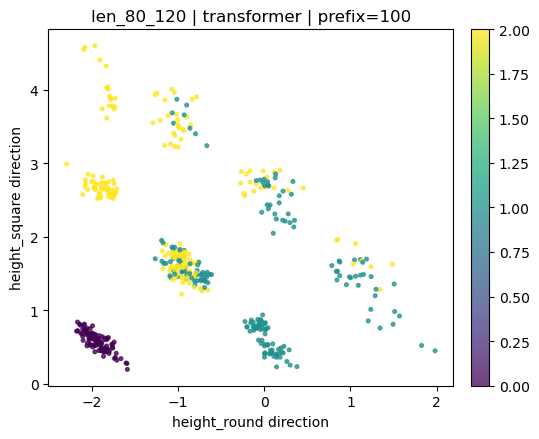

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck25_cfg_next_token_len_80_120/figures/directions/len_80_120_mamba_direction_heatmap.png


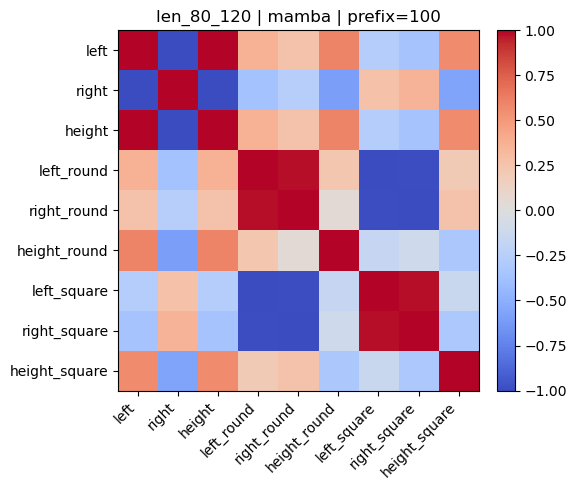

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck25_cfg_next_token_len_80_120/figures/supervised_projection/len_80_120_mamba_height_projection.png


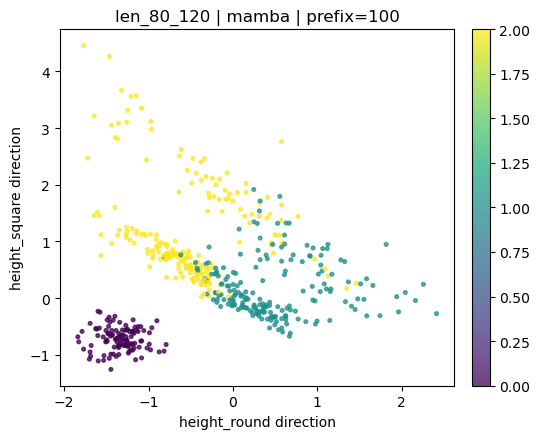

In [22]:
def cosine_matrix(vectors):
    names = list(vectors)
    W = np.stack([vectors[name] for name in names])
    W = W / (np.linalg.norm(W, axis=1, keepdims=True) + 1e-12)
    return names, W @ W.T


def plot_direction_cosine_heatmap(result, title, save_stem):
    fitted = result['fitted']
    vectors = {}
    for key, value in fitted.items():
        if not key.startswith('ridge_'):
            continue
        weight = extract_linear_weight(value['probe'])
        if weight.ndim == 1 and weight.size:
            vectors[key.replace('ridge_', '')] = weight
    if len(vectors) < 2:
        return
    names, C = cosine_matrix(vectors)
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(C, vmin=-1, vmax=1, cmap='coolwarm')
    ax.set_xticks(range(len(names)), names, rotation=45, ha='right')
    ax.set_yticks(range(len(names)), names)
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    finalize_figure(fig, 'directions', save_stem)
    plt.show()


def plot_supervised_projection(result, title, save_stem, max_points=PCA_MAX_POINTS):
    data = result['data']
    labels = data['labels']
    X = data['X']
    fitted = result['fitted']
    if len(labels) > max_points:
        idx = np.random.default_rng(SEED).choice(len(labels), size=max_points, replace=False)
        X = X[idx]
        labels = labels.iloc[idx].reset_index(drop=True)
    wx = extract_linear_weight(fitted['ridge_height_round']['probe'])
    wy = extract_linear_weight(fitted['ridge_height_square']['probe'])
    Z = np.stack([X @ wx, X @ wy], axis=1)
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    sc = ax.scatter(Z[:, 0], Z[:, 1], c=labels['top_type_class'], s=7, cmap='viridis', alpha=0.75)
    ax.set_xlabel('height_round direction')
    ax.set_ylabel('height_square direction')
    ax.set_title(title)
    fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
    finalize_figure(fig, 'supervised_projection', save_stem)
    plt.show()


for length_bin in DYCK23_LENGTH_BINS:
    for model_type in MODEL_TYPES:
        result = fixed_probe_results[(length_bin, model_type)]
        title = f'{length_bin} | {model_type} | prefix={result["prefix"]}'
        plot_direction_cosine_heatmap(result, title, f'{length_bin}_{model_type}_direction_heatmap')
        plot_supervised_projection(result, title, f'{length_bin}_{model_type}_height_projection')


这个 cell 生成 `figures/directions/` 的 direction cosine heatmap，以及 `figures/supervised_projection/` 的两个 supervised counter direction 投影图。heatmap 看不同 probe direction 是否同向、反向或接近正交；projection 图把 hidden state 投到两个 per-type height 方向上。

Dyck(2,5) 结果里，总 height 的线性结构非常稳定：`cos_height_left_minus_right` 对四个模型都是 1，说明 total height 基本就是 open-count minus close-count 的方向。与此同时，固定长度和固定 prefix 会让累计 left/right、round/square counter 彼此高度相关，所以 raw counter directions 不应该被理解成独立坐标轴。

supervised projection 的强弱和 lattice summary 对齐：Transformer 的 per-type height 投影最像整数三角格；RNN/LSTM 的 total-depth 轴很稳，但 per-type 分解更受约束；Mamba 有可见结构，不过点云更连续、更散。

## 5. All-prefix counter lattice views

Fixed-prefix projections are intentionally controlled, but Dyck-(2,5) has a depth parity constraint at a single prefix. These all-prefix views balance by `(height_round, height_square)` and refit just those two counter probes, making the available integer lattice points easier to see.


saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck25_cfg_next_token_len_80_120/figures/counter_lattices/len_80_120_rnn_height_round_vs_height_square_all_prefixes.png


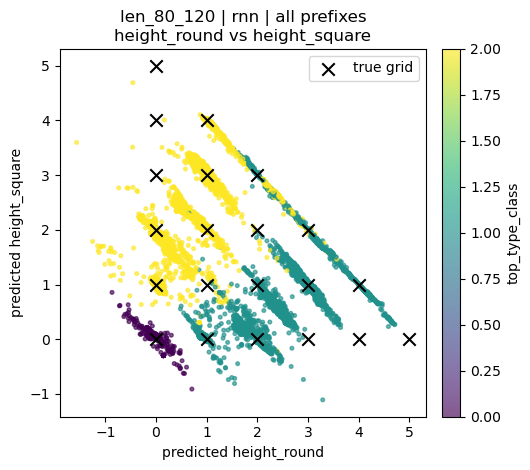

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck25_cfg_next_token_len_80_120/figures/counter_lattices/len_80_120_lstm_height_round_vs_height_square_all_prefixes.png


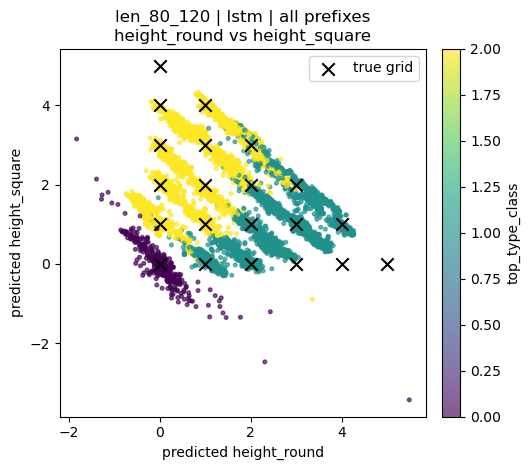

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck25_cfg_next_token_len_80_120/figures/counter_lattices/len_80_120_transformer_height_round_vs_height_square_all_prefixes.png


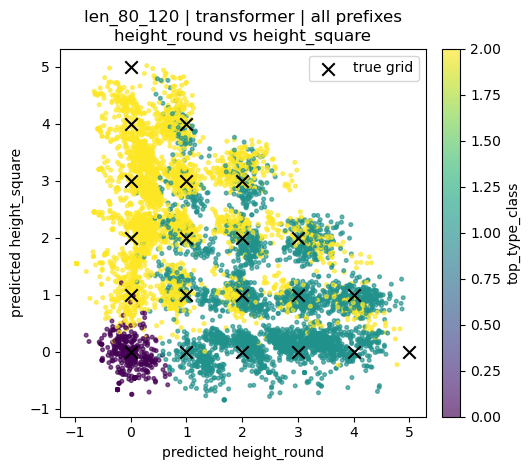

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck25_cfg_next_token_len_80_120/figures/counter_lattices/len_80_120_mamba_height_round_vs_height_square_all_prefixes.png


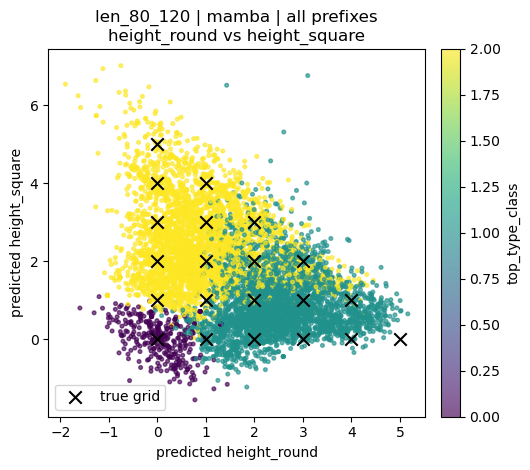

,length_bin,model,prefix,x_target,y_target,x_mae_to_integer,y_mae_to_integer,joint_round_exact,n_grid_points,n
0,len_80_120,rnn,all,height_round,height_square,0.565539,0.558266,0.479275,21,10036
1,len_80_120,lstm,all,height_round,height_square,0.531417,0.537018,0.513950,21,10036
2,len_80_120,transformer,all,height_round,height_square,0.252627,0.228926,0.800618,21,10036
3,len_80_120,mamba,all,height_round,height_square,0.465345,0.442617,0.457553,21,10036


In [23]:
def balance_data_by_counter_pair(data, x_target='height_round', y_target='height_square', seed=0, max_per_pair=512, min_per_pair=8):
    labels = data['labels']
    rng = np.random.default_rng(seed)
    chosen = []
    for _, idx in labels.groupby([x_target, y_target]).indices.items():
        idx = np.asarray(idx)
        if len(idx) < min_per_pair:
            continue
        take = min(len(idx), max_per_pair)
        chosen.append(rng.choice(idx, size=take, replace=False))
    if not chosen:
        return data
    chosen = np.sort(np.concatenate(chosen))
    return {'X': data['X'][chosen], 'labels': labels.iloc[chosen].reset_index(drop=True), 'run_dir': data['run_dir']}


def fit_counter_pair_result(data, x_target='height_round', y_target='height_square', seed=0):
    X = data['X']
    labels = data['labels']
    train_idx, test_idx = _split_indices(len(labels), seed=seed)
    fitted = {}
    for target in [x_target, y_target, 'height']:
        if target not in labels:
            continue
        fitted[f'ridge_{target}'] = fit_ridge_train_test(
            X[train_idx],
            labels[target].to_numpy()[train_idx],
            X[test_idx],
            labels[target].to_numpy()[test_idx],
            target,
        )
    return {'data': data, 'fitted': fitted, 'table': pd.DataFrame(), 'prefix': 'all'}



def _counter_projection(result, target):
    X = result['data']['X']
    probe = result['fitted'][f'ridge_{target}']['probe']
    weight = extract_linear_weight(probe)
    intercept = float(probe.get('intercept', 0.0))
    return X @ weight + intercept


def counter_grid_scores(result, target_pairs=GRID_TARGET_PAIRS):
    labels = result['data']['labels']
    rows = []
    for x_target, y_target in target_pairs:
        if f'ridge_{x_target}' not in result['fitted'] or f'ridge_{y_target}' not in result['fitted']:
            continue
        x_pred = _counter_projection(result, x_target)
        y_pred = _counter_projection(result, y_target)
        x_true = labels[x_target].to_numpy(dtype=float)
        y_true = labels[y_target].to_numpy(dtype=float)
        x_round = np.rint(x_pred)
        y_round = np.rint(y_pred)
        grid_points = labels[[x_target, y_target]].drop_duplicates()
        rows.append({
            'x_target': x_target,
            'y_target': y_target,
            'x_mae_to_integer': float(np.abs(x_pred - x_true).mean()),
            'y_mae_to_integer': float(np.abs(y_pred - y_true).mean()),
            'joint_round_exact': float(((x_round == x_true) & (y_round == y_true)).mean()),
            'n_grid_points': int(len(grid_points)),
            'n': int(len(labels)),
        })
    return rows


def plot_counter_grid_projection(
    result,
    title,
    save_stem,
    x_target='height_round',
    y_target='height_square',
    max_points=7_000,
    section='counter_lattices',
):
    data = result['data']
    labels = data['labels']
    if f'ridge_{x_target}' not in result['fitted'] or f'ridge_{y_target}' not in result['fitted']:
        return
    x_pred = _counter_projection(result, x_target)
    y_pred = _counter_projection(result, y_target)
    idx = np.arange(len(labels))
    if len(idx) > max_points:
        idx = np.random.default_rng(SEED).choice(idx, size=max_points, replace=False)
    color_target = 'top_type_class' if 'top_type_class' in labels else y_target
    fig, ax = plt.subplots(figsize=(5.4, 4.8))
    sc = ax.scatter(
        x_pred[idx],
        y_pred[idx],
        c=labels[color_target].to_numpy()[idx],
        s=7,
        cmap='viridis',
        alpha=0.65,
    )
    grid_points = labels[[x_target, y_target]].drop_duplicates().sort_values([x_target, y_target])
    ax.scatter(
        grid_points[x_target],
        grid_points[y_target],
        marker='x',
        s=80,
        linewidths=1.5,
        color='black',
        label='true grid',
    )
    ax.set_xlabel(f'predicted {x_target}')
    ax.set_ylabel(f'predicted {y_target}')
    ax.set_title(title)
    ax.legend(loc='best')
    fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04, label=color_target)
    finalize_figure(fig, section, save_stem)
    plt.show()
    plt.close(fig)

lattice_rows = []
for length_bin in DYCK23_LENGTH_BINS:
    for model_type in MODEL_TYPES:
        raw = run_arrays[(length_bin, model_type)]
        data = balance_data_by_counter_pair(raw, seed=SEED)
        result = fit_counter_pair_result(data, seed=SEED)
        base = {'length_bin': length_bin, 'model': model_type, 'prefix': 'all'}
        for row in counter_grid_scores(result, target_pairs=[('height_round', 'height_square')]):
            lattice_rows.append({**base, **row})
        plot_counter_grid_projection(
            result,
            f'{length_bin} | {model_type} | all prefixes\nheight_round vs height_square',
            f'{length_bin}_{model_type}_height_round_vs_height_square_all_prefixes',
            x_target='height_round',
            y_target='height_square',
            max_points=7_000,
            section='counter_lattices',
        )

counter_lattice_df = pd.DataFrame(lattice_rows)
counter_lattice_df.to_csv(RESULTS_ROOT / 'counter_lattice_summary.csv', index=False)
counter_lattice_df


做 all-prefix counter lattice：把所有 prefix 的 hidden state 按 `(height_round, height_square)` 平衡采样，再拟合两个 counter direction，并生成 `counter_lattice_summary.csv` 和 `figures/counter_lattices/` 下的 lattice scatter。

Dyck(2,5) 的合法状态满足 `height_round >= 0`、`height_square >= 0`、`height_round + height_square <= 5`，所以真实格点是 21 个三角形格点，而不是矩形网格。这里最清楚的是 Transformer：`joint_round_exact=0.8006`，到整数格点的 MAE 是 0.2526/0.2289。LSTM 和 RNN 有 lattice 趋势但更粗，`joint_round_exact` 分别是 0.5140 和 0.4793；Mamba 是 0.4576，点云更连续。

- x = ridge probe 预测的 height_round
- y = ridge probe 预测的 height_square
- 颜色 = top_type_class
- 0 紫色: empty
- 1 青色: top round
- 2 黄色: top square
- 黑色 x: 真实合法整数格点

这说明四个模型都保留了 Dyck counter 信息，但 per-type counter 的“整数格点化”程度差异很大：Transformer 最像显式二维 counter，RNN 更像沿 total-depth/trade-off 方向形成斜带。

## 6. Prefix sweep

In [24]:
def run_prefix_sweep_for_run(length_bin, model_type):
    rows = []
    directions = {}
    raw = run_arrays[(length_bin, model_type)]
    for prefix in SWEEP_PREFIX_BY_BIN[length_bin]:
        data = balance_data_by_label(select_prefix(raw, prefix), seed=SEED)
        if len(data['labels']) < 32:
            continue
        fitted, table = run_stack_probes(data, seed=SEED)
        lookup = {(r.probe_type, r.target): r for r in table.itertuples()}
        row = {'length_bin': length_bin, 'model': model_type, 'prefix': prefix, 'n': len(data['labels'])}
        for target in ['height', 'height_round', 'height_square']:
            key = ('ridge', target)
            if key in lookup:
                row[f'{target}_r2'] = lookup[key].r2
        for target in ['top_type_class', 'depth_top_class', 'legal_next_class']:
            key = ('logistic', target)
            if key in lookup:
                row[f'{target}_accuracy'] = lookup[key].accuracy
        rows.append(row)
        direction_row = {}
        for target in RIDGE_TARGETS:
            probe = fitted.get(f'ridge_{target}')
            if probe:
                direction_row[target] = extract_linear_weight(probe['probe'])
        directions[prefix] = direction_row
    return {'rows': pd.DataFrame(rows), 'directions': directions}


prefix_sweep_results = {}
for length_bin in DYCK23_LENGTH_BINS:
    for model_type in MODEL_TYPES:
        print(f'prefix sweep: {length_bin} {model_type}')
        prefix_sweep_results[(length_bin, model_type)] = run_prefix_sweep_for_run(length_bin, model_type)

prefix_sweep_df = pd.concat([v['rows'] for v in prefix_sweep_results.values()], ignore_index=True)
prefix_sweep_df.to_csv(RESULTS_ROOT / 'prefix_sweep_summary.csv', index=False)
prefix_sweep_df


prefix sweep: len_80_120 rnn
prefix sweep: len_80_120 lstm
prefix sweep: len_80_120 transformer
prefix sweep: len_80_120 mamba


,length_bin,model,prefix,n,height_r2,height_round_r2,height_square_r2,top_type_class_accuracy,depth_top_class_accuracy,legal_next_class_accuracy
0,len_80_120,rnn,84,640,0.999429,0.793707,0.802293,1.000000,1.000000,0.868750
1,len_80_120,rnn,88,614,0.999227,0.791096,0.819955,1.000000,1.000000,0.863636
2,len_80_120,rnn,92,592,0.999276,0.836797,0.863801,1.000000,1.000000,0.777027
3,len_80_120,rnn,96,555,0.995978,0.692047,0.624213,1.000000,1.000000,0.812950
4,len_80_120,rnn,100,501,0.986829,0.121481,0.026519,1.000000,1.000000,0.792000
5,len_80_120,rnn,104,440,0.995871,0.730757,0.767794,1.000000,1.000000,0.700000
6,len_80_120,rnn,108,335,0.985445,0.724922,0.731989,1.000000,1.000000,0.642857
7,len_80_120,rnn,112,247,0.985670,0.776947,0.785729,1.000000,0.983871,0.580645
8,len_80_120,rnn,116,137,0.999897,0.718786,0.636337,1.000000,1.000000,0.529412
9,len_80_120,rnn,120,51,1.000000,1.000000,1.000000,NaN,NaN,NaN


这个 cell 做 prefix sweep：沿 `len_80_120` 的 prefix 84-120 重复筛样本、平衡类别、拟合 probe，并保存 `prefix_sweep_summary.csv`。它本身主要产出表，不画最终 sweep 图。

表里的关键现象很清楚：在非退化 prefix 84-116 上，总 `height_r2` 基本稳定。RNN 是 0.9854-0.9999，LSTM 是 0.9945-0.9996，Transformer 是 0.9657-0.9883，Mamba 是 0.8981-0.9639。`top_type_class_accuracy` 也几乎满分，只有 Mamba 偶尔降到 0.976 左右。

真正下降的是 `legal_next_class_accuracy`：前段大约 0.856-0.883，到后段明显下降。prefix 116 时 RNN 0.5588、LSTM 0.6471、Transformer 0.4706、Mamba 0.7353。prefix 120 的分类列是 NaN，因为这个位置样本/类别退化，不能和前面的点直接比较。

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck25_cfg_next_token_len_80_120/figures/sweeps/prefix_sweep.png


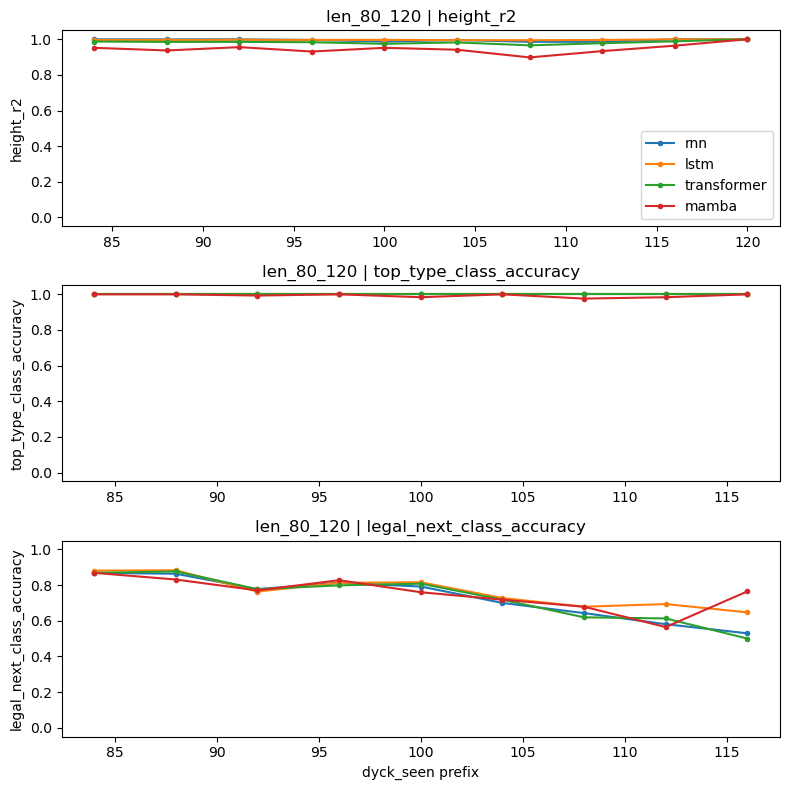

In [25]:
def plot_prefix_sweep(df):
    metrics = ['height_r2', 'top_type_class_accuracy', 'legal_next_class_accuracy']
    fig, axes = plt.subplots(len(metrics), len(DYCK23_LENGTH_BINS), figsize=(8, 8), sharex=False, sharey='row')
    axes = np.asarray(axes).reshape(len(metrics), len(DYCK23_LENGTH_BINS))
    for col, length_bin in enumerate(DYCK23_LENGTH_BINS):
        sub_bin = df.loc[df['length_bin'] == length_bin]
        for row, metric in enumerate(metrics):
            ax = axes[row, col]
            for model_type in MODEL_TYPES:
                sub = sub_bin.loc[sub_bin['model'] == model_type]
                if metric in sub:
                    ax.plot(sub['prefix'], sub[metric], marker='o', ms=3, label=model_type)
            ax.set_title(f'{length_bin} | {metric}')
            ax.set_ylim(-0.05, 1.05)
            if row == len(metrics) - 1:
                ax.set_xlabel('dyck_seen prefix')
            if col == 0:
                ax.set_ylabel(metric)
            if row == 0 and col == len(DYCK23_LENGTH_BINS) - 1:
                ax.legend(loc='lower right')
    finalize_figure(fig, 'sweeps', 'prefix_sweep')
    plt.show()


plot_prefix_sweep(prefix_sweep_df)


把 prefix sweep 表画成 `figures/sweeps/prefix_sweep.png`。三行分别展示 height 可读性、top type 可读性、legal-next 可读性；单列对应 `len_80_120`。

图上前两行几乎是平的：total height 和 top type 在整个 80-120 长度范围内都很容易读出。第三行才是主要差异，legal-next 随 prefix 后移整体下降，尤其 Transformer/RNN 在靠后位置掉得明显；Mamba 的 height 读出最低，但 legal-next 在最后几个非退化点反而没有 Transformer/RNN 掉得那么低。

所以这组结果更像是：模型学到了 Dyck stack state，但“完整合法 next-action 集合”还需要额外的剩余长度/终止信息，越接近序列尾部越难稳定线性读出。

## 7. Direction arithmetic

In [26]:
def cosine(a, b):
    a = np.asarray(a)
    b = np.asarray(b)
    return float(a @ b / ((np.linalg.norm(a) + 1e-12) * (np.linalg.norm(b) + 1e-12)))


def _counter_pair_column(x_target, y_target):
    return f'cos_{x_target}_{y_target}'


def direction_arithmetic_table(prefix_sweep_results):
    rows = []
    for (length_bin, model_type), result in prefix_sweep_results.items():
        for prefix, directions in result['directions'].items():
            if not {'height', 'height_round', 'height_square'}.issubset(directions):
                continue
            summed = directions['height_round'] + directions['height_square']
            row = {
                'length_bin': length_bin,
                'model': model_type,
                'prefix': prefix,
                'cos_height_round': cosine(directions['height'], directions['height_round']),
                'cos_height_square': cosine(directions['height'], directions['height_square']),
                'cos_round_square': cosine(directions['height_round'], directions['height_square']),
                'cos_height_sum': cosine(directions['height'], summed),
            }
            for x_target, y_target in COUNTER_TARGET_PAIRS:
                if x_target in directions and y_target in directions:
                    pair_col = _counter_pair_column(x_target, y_target)
                    wx = directions[x_target]
                    wy = directions[y_target]
                    w_sum = wx + wy
                    w_diff = wx - wy
                    row[pair_col] = cosine(wx, wy)
                    row[f'{pair_col}_sum_diff'] = cosine(w_sum, w_diff)
                    total_target = COUNTER_TOTAL_TARGETS.get((x_target, y_target))
                    if total_target in directions:
                        wt = directions[total_target]
                        row[f'{pair_col}_total_sum'] = cosine(wt, w_sum)
                        row[f'{pair_col}_total_diff'] = cosine(wt, w_diff)
            rows.append(row)
    return pd.DataFrame(rows)


direction_arithmetic_df = direction_arithmetic_table(prefix_sweep_results)
direction_arithmetic_df.to_csv(RESULTS_ROOT / 'direction_arithmetic_summary.csv', index=False)
direction_arithmetic_df


,length_bin,model,prefix,cos_height_round,cos_height_square,cos_round_square,cos_height_sum,cos_height_round_height_square,cos_height_round_height_square_sum_diff,cos_height_round_height_square_total_sum,cos_height_round_height_square_total_diff,cos_left_round_left_square,cos_left_round_left_square_sum_diff,cos_left_round_left_square_total_sum,cos_left_round_left_square_total_diff,cos_right_round_right_square,cos_right_round_right_square_sum_diff,cos_right_round_right_square_total_sum,cos_right_round_right_square_total_diff
0,len_80_120,rnn,84,-0.180665,0.254918,-0.997106,1.0,-0.997106,-0.218265,1.0,-0.218265,-0.999868,-0.213793,1.000000,-0.213793,-0.999826,0.136830,1.000000,0.136830
1,len_80_120,rnn,88,0.045857,0.091294,-0.990590,1.0,-0.990590,-0.022880,1.0,-0.022880,-0.999935,0.351792,1.000000,0.351792,-0.999931,-0.367771,1.000000,-0.367771
2,len_80_120,rnn,92,0.281875,-0.234822,-0.998814,1.0,-0.998814,0.258578,1.0,0.258578,-0.999976,0.591358,1.000000,0.591358,-0.999967,-0.578646,1.000000,-0.578646
3,len_80_120,rnn,96,0.411945,-0.335458,-0.996599,1.0,-0.996599,0.374656,1.0,0.374656,-0.999909,0.382559,1.000000,0.382559,-0.999868,-0.304215,1.000000,-0.304215
4,len_80_120,rnn,100,-0.194868,0.276866,-0.996440,1.0,-0.996440,-0.236498,1.0,-0.236498,-0.999939,-0.093043,1.000000,-0.093043,-0.999942,0.031554,1.000000,0.031554
5,len_80_120,rnn,104,0.664539,-0.590676,-0.995493,1.0,-0.995493,0.629734,1.0,0.629734,-0.999287,-0.031148,1.000000,-0.031148,-0.999384,0.433824,1.000000,0.433824
6,len_80_120,rnn,108,-0.142460,0.582432,-0.887562,1.0,-0.887562,-0.395195,1.0,-0.395195,-0.998893,0.481980,1.000000,0.481980,-0.999097,-0.521990,1.000000,-0.521990
7,len_80_120,rnn,112,0.290779,0.310811,-0.819025,1.0,-0.819025,-0.011547,1.0,-0.011547,-0.998582,-0.107276,1.000000,-0.107276,-0.998473,0.109292,1.000000,0.109292
8,len_80_120,rnn,116,-0.711593,0.731156,-0.999601,1.0,-0.999601,-0.721590,1.0,-0.721590,-0.999995,-0.147415,1.000000,-0.147415,-0.999995,0.036161,1.000000,0.036161
9,len_80_120,rnn,120,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,-1.000000,0.289186,0.705675,0.725186,-1.000000,0.289186,0.705675,0.725186


计算 direction arithmetic，并保存 `direction_arithmetic_summary.csv`。核心问题是：`height` direction 是否接近 `height_round + height_square`，以及 raw per-type directions、sum/diff basis 在 prefix sweep 中怎样变化。

Dyck(2,5) 的结果非常干净：对所有模型，在 prefix 84-116 上 `cos_height_sum` 都等于 1.0，说明 total depth direction 和 `height_round + height_square` 的方向完全一致。prefix 120 的 0 是退化点，不应解释成结构崩塌。

需要注意的是，`height_round` 和 `height_square` 的 raw directions 经常强烈反相关，这是三角约束 `height_round + height_square <= 5`、固定 prefix、类别平衡共同造成的。sum/diff basis 才更适合看模型是否把“总深度”和“括号类型差异”拆成两个轴。

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck25_cfg_next_token_len_80_120/figures/sweeps/direction_arithmetic.png


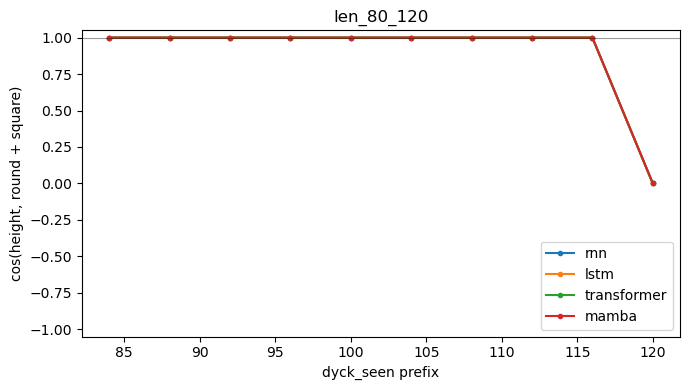

In [27]:
def plot_direction_arithmetic(df):
    fig, axes = plt.subplots(1, len(DYCK23_LENGTH_BINS), figsize=(7, 4), sharey=True)
    axes = np.atleast_1d(axes)
    for ax, length_bin in zip(axes, DYCK23_LENGTH_BINS):
        sub_bin = df.loc[df['length_bin'] == length_bin]
        for model_type in MODEL_TYPES:
            sub = sub_bin.loc[sub_bin['model'] == model_type]
            ax.plot(sub['prefix'], sub['cos_height_sum'], marker='o', ms=3, label=model_type)
        ax.axhline(1.0, color='black', lw=0.8, alpha=0.4)
        ax.set_title(length_bin)
        ax.set_xlabel('dyck_seen prefix')
        ax.set_ylim(-1.05, 1.05)
    axes[0].set_ylabel('cos(height, round + square)')
    axes[-1].legend(loc='lower right')
    finalize_figure(fig, 'sweeps', 'direction_arithmetic')
    plt.show()


plot_direction_arithmetic(direction_arithmetic_df)


`figures/sweeps/direction_arithmetic.png` 展示不同模型在 `len_80_120` 里 `cos(height, height_round + height_square)` 随 prefix 的变化。

这张图基本是一条贴着 1 的水平线：除 prefix 120 这个退化端点外，四个模型都稳定满足 `height = height_round + height_square` 的线性关系。也就是说，虽然 next-token accuracy 只有 0.53 左右，hidden state 里的 Dyck depth 算术关系其实非常稳。

## 8. Counter orthogonality plots

The fixed-prefix table gives one cosine per model/bin/counter pair. The sweep plot shows whether those cosines stay stable as the prefix moves through each length bin.


saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck25_cfg_next_token_len_80_120/figures/counter_orthogonality/fixed_prefix_counter_cosines.png


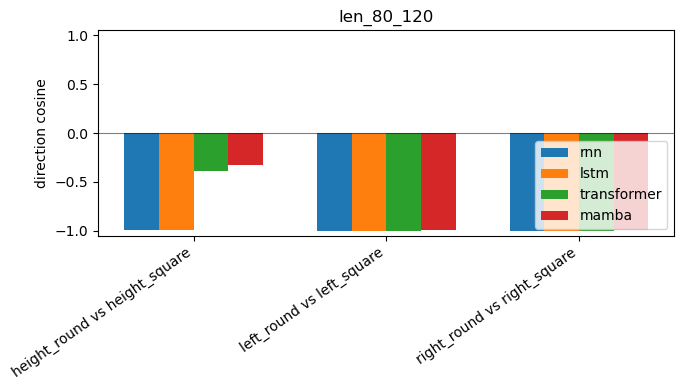

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck25_cfg_next_token_len_80_120/figures/counter_orthogonality/fixed_prefix_sum_diff_orthogonality.png


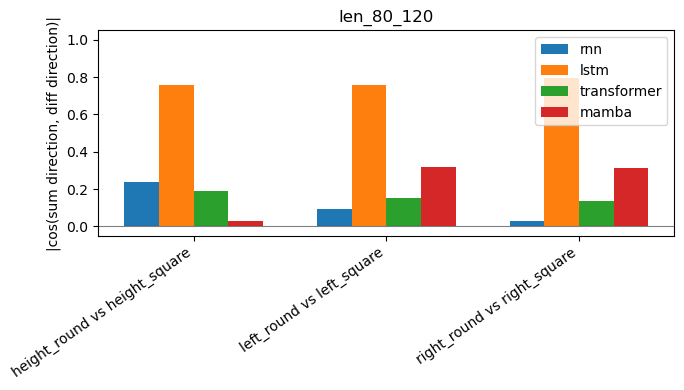

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck25_cfg_next_token_len_80_120/figures/counter_orthogonality/prefix_sweep_counter_cosines.png


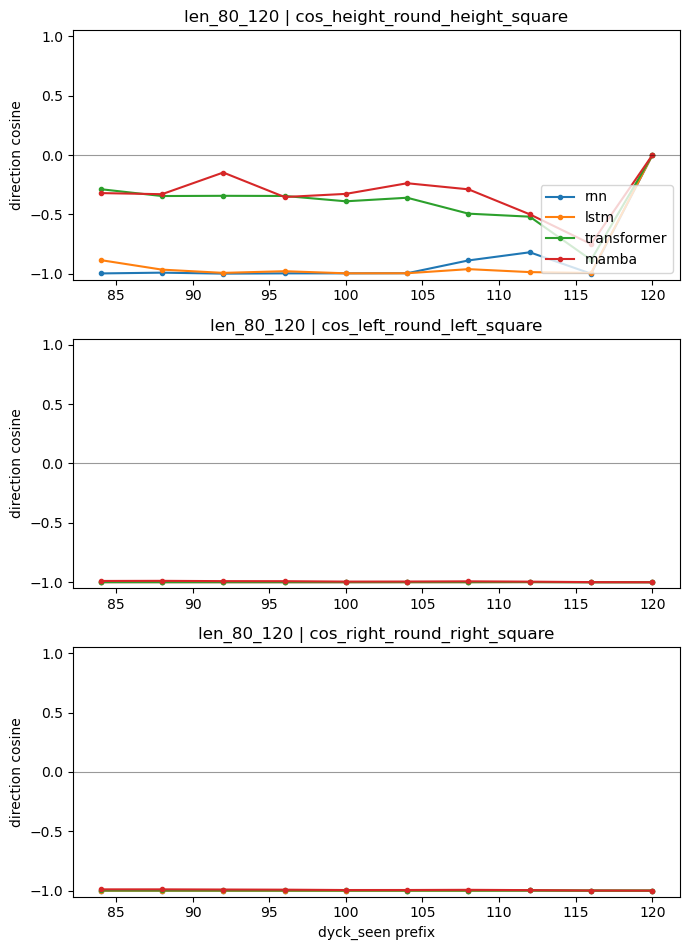

saved figure -> /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck25_cfg_next_token_len_80_120/figures/counter_orthogonality/prefix_sweep_sum_diff_orthogonality.png


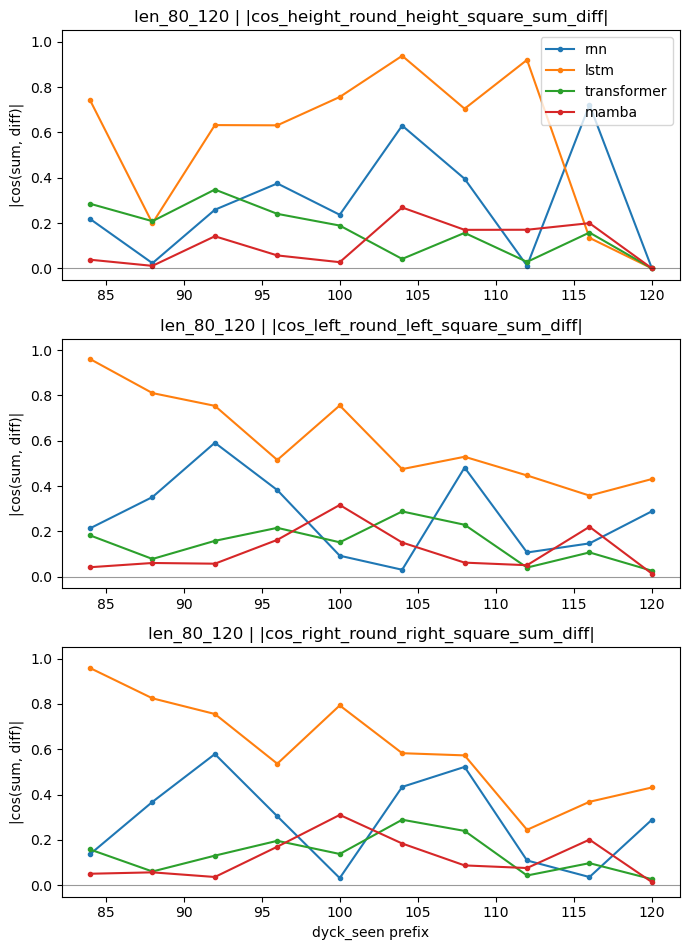

,length_bin,model,prefix,x_target,y_target,cosine,cos_sum_diff,abs_cos_sum_diff,cos_total_sum,cos_total_diff
0,len_80_120,rnn,100,height_round,height_square,-0.996440,-0.236498,0.236498,1.0,-0.236498
1,len_80_120,rnn,100,left_round,left_square,-0.999939,-0.093043,0.093043,1.0,-0.093043
2,len_80_120,rnn,100,right_round,right_square,-0.999942,0.031554,0.031554,1.0,0.031554
3,len_80_120,lstm,100,height_round,height_square,-0.996068,-0.755997,0.755997,1.0,-0.755997
4,len_80_120,lstm,100,left_round,left_square,-0.999963,0.755813,0.755813,1.0,0.755813
5,len_80_120,lstm,100,right_round,right_square,-0.999975,-0.793158,0.793158,1.0,-0.793158
6,len_80_120,transformer,100,height_round,height_square,-0.389727,-0.188881,0.188881,1.0,-0.188881
7,len_80_120,transformer,100,left_round,left_square,-0.998670,-0.152263,0.152263,1.0,-0.152263
8,len_80_120,transformer,100,right_round,right_square,-0.998656,0.137937,0.137937,1.0,0.137937
9,len_80_120,mamba,100,height_round,height_square,-0.327224,0.027349,0.027349,1.0,0.027349


In [28]:
def plot_fixed_counter_orthogonality(df):
    if df.empty:
        return
    pair_names = [f'{x} vs {y}' for x, y in COUNTER_TARGET_PAIRS]
    fig, axes = plt.subplots(1, len(DYCK23_LENGTH_BINS), figsize=(7, 4), sharey=True)
    axes = np.atleast_1d(axes)
    for ax, length_bin in zip(axes, DYCK23_LENGTH_BINS):
        sub = df.loc[df['length_bin'] == length_bin].copy()
        sub['pair'] = sub['x_target'] + ' vs ' + sub['y_target']
        x = np.arange(len(pair_names))
        width = 0.18
        for offset, model_type in enumerate(MODEL_TYPES):
            vals = []
            for pair in pair_names:
                part = sub.loc[(sub['model'] == model_type) & (sub['pair'] == pair), 'cosine']
                vals.append(float(part.iloc[0]) if len(part) else np.nan)
            ax.bar(x + (offset - 1.5) * width, vals, width=width, label=model_type)
        ax.axhline(0.0, color='black', lw=0.8, alpha=0.5)
        ax.set_xticks(x, pair_names, rotation=35, ha='right')
        ax.set_title(length_bin)
        ax.set_ylim(-1.05, 1.05)
    axes[0].set_ylabel('direction cosine')
    axes[-1].legend(loc='lower right')
    finalize_figure(fig, 'counter_orthogonality', 'fixed_prefix_counter_cosines')
    plt.show()
    plt.close(fig)


def plot_counter_orthogonality_sweep(df):
    columns = [_counter_pair_column(x, y) for x, y in COUNTER_TARGET_PAIRS]
    columns = [col for col in columns if col in df]
    if not columns:
        return
    fig, axes = plt.subplots(len(columns), len(DYCK23_LENGTH_BINS), figsize=(7, 3.2 * len(columns)), sharey=True)
    axes = np.asarray(axes).reshape(len(columns), len(DYCK23_LENGTH_BINS))
    for row, col_name in enumerate(columns):
        for ax, length_bin in zip(axes[row], DYCK23_LENGTH_BINS):
            sub_bin = df.loc[df['length_bin'] == length_bin]
            for model_type in MODEL_TYPES:
                sub = sub_bin.loc[sub_bin['model'] == model_type]
                ax.plot(sub['prefix'], sub[col_name], marker='o', ms=3, label=model_type)
            ax.axhline(0.0, color='black', lw=0.8, alpha=0.4)
            ax.set_title(f'{length_bin} | {col_name}')
            ax.set_ylim(-1.05, 1.05)
            if row == len(columns) - 1:
                ax.set_xlabel('dyck_seen prefix')
            if ax is axes[row][0]:
                ax.set_ylabel('direction cosine')
    axes[0][-1].legend(loc='lower right')
    finalize_figure(fig, 'counter_orthogonality', 'prefix_sweep_counter_cosines')
    plt.show()
    plt.close(fig)


def plot_fixed_counter_basis_orthogonality(df):
    if df.empty or 'abs_cos_sum_diff' not in df:
        return
    pair_names = [f'{x} vs {y}' for x, y in COUNTER_TARGET_PAIRS]
    fig, axes = plt.subplots(1, len(DYCK23_LENGTH_BINS), figsize=(7, 4), sharey=True)
    axes = np.atleast_1d(axes)
    for ax, length_bin in zip(axes, DYCK23_LENGTH_BINS):
        sub = df.loc[df['length_bin'] == length_bin].copy()
        sub['pair'] = sub['x_target'] + ' vs ' + sub['y_target']
        x = np.arange(len(pair_names))
        width = 0.18
        for offset, model_type in enumerate(MODEL_TYPES):
            vals = []
            for pair in pair_names:
                part = sub.loc[(sub['model'] == model_type) & (sub['pair'] == pair), 'abs_cos_sum_diff']
                vals.append(float(part.iloc[0]) if len(part) else np.nan)
            ax.bar(x + (offset - 1.5) * width, vals, width=width, label=model_type)
        ax.axhline(0.0, color='black', lw=0.8, alpha=0.5)
        ax.set_xticks(x, pair_names, rotation=35, ha='right')
        ax.set_title(length_bin)
        ax.set_ylim(-0.05, 1.05)
    axes[0].set_ylabel('|cos(sum direction, diff direction)|')
    axes[-1].legend(loc='upper right')
    finalize_figure(fig, 'counter_orthogonality', 'fixed_prefix_sum_diff_orthogonality')
    plt.show()
    plt.close(fig)


def plot_counter_basis_sweep(df):
    columns = [f'{_counter_pair_column(x, y)}_sum_diff' for x, y in COUNTER_TARGET_PAIRS]
    columns = [col for col in columns if col in df]
    if not columns:
        return
    fig, axes = plt.subplots(len(columns), len(DYCK23_LENGTH_BINS), figsize=(7, 3.2 * len(columns)), sharey=True)
    axes = np.asarray(axes).reshape(len(columns), len(DYCK23_LENGTH_BINS))
    for row, col_name in enumerate(columns):
        for ax, length_bin in zip(axes[row], DYCK23_LENGTH_BINS):
            sub_bin = df.loc[df['length_bin'] == length_bin]
            for model_type in MODEL_TYPES:
                sub = sub_bin.loc[sub_bin['model'] == model_type]
                ax.plot(sub['prefix'], sub[col_name].abs(), marker='o', ms=3, label=model_type)
            ax.axhline(0.0, color='black', lw=0.8, alpha=0.4)
            ax.set_title(f'{length_bin} | |{col_name}|')
            ax.set_ylim(-0.05, 1.05)
            if row == len(columns) - 1:
                ax.set_xlabel('dyck_seen prefix')
            if ax is axes[row][0]:
                ax.set_ylabel('|cos(sum, diff)|')
    axes[0][-1].legend(loc='upper right')
    finalize_figure(fig, 'counter_orthogonality', 'prefix_sweep_sum_diff_orthogonality')
    plt.show()
    plt.close(fig)


def fixed_counter_orthogonality_table(fixed_probe_results):
    rows = []
    for (length_bin, model_type), result in fixed_probe_results.items():
        directions = {}
        for target in RIDGE_TARGETS:
            probe = result['fitted'].get(f'ridge_{target}')
            if probe and probe.get('probe') is not None:
                weight = extract_linear_weight(probe['probe'])
                if weight.ndim == 1 and weight.size:
                    directions[target] = weight
        for x_target, y_target in COUNTER_TARGET_PAIRS:
            if x_target not in directions or y_target not in directions:
                continue
            wx = directions[x_target]
            wy = directions[y_target]
            w_sum = wx + wy
            w_diff = wx - wy
            row = {
                'length_bin': length_bin,
                'model': model_type,
                'prefix': result['prefix'],
                'x_target': x_target,
                'y_target': y_target,
                'cosine': cosine(wx, wy),
                'cos_sum_diff': cosine(w_sum, w_diff),
                'abs_cos_sum_diff': abs(cosine(w_sum, w_diff)),
            }
            total_target = COUNTER_TOTAL_TARGETS.get((x_target, y_target))
            if total_target in directions:
                wt = directions[total_target]
                row['cos_total_sum'] = cosine(wt, w_sum)
                row['cos_total_diff'] = cosine(wt, w_diff)
            rows.append(row)
    return pd.DataFrame(rows)


fixed_counter_orthogonality_df = fixed_counter_orthogonality_table(fixed_probe_results)
fixed_counter_orthogonality_df.to_csv(RESULTS_ROOT / 'fixed_counter_orthogonality_summary.csv', index=False)
fixed_counter_grid_df = fixed_counter_orthogonality_df.copy()


plot_fixed_counter_orthogonality(fixed_counter_orthogonality_df)
plot_fixed_counter_basis_orthogonality(fixed_counter_orthogonality_df)
plot_counter_orthogonality_sweep(direction_arithmetic_df)
plot_counter_basis_sweep(direction_arithmetic_df)
fixed_counter_grid_df


counter orthogonality 的汇总图：`fixed_prefix_counter_cosines.png`、`fixed_prefix_sum_diff_orthogonality.png`、`prefix_sweep_counter_cosines.png`、`prefix_sweep_sum_diff_orthogonality.png`，并展示 `fixed_counter_grid_df`。

固定 prefix=100 时，`height_round` vs `height_square` 的 cosine 分成两类：RNN/LSTM 几乎完全反向（-0.9964/-0.9961），Transformer/Mamba 没那么反向（-0.3897/-0.3272）。这和前面的 fixed-prefix probe 一致：RNN/LSTM 在这个切片里更像用 total-depth/trade-off 方向组织 per-type height；Transformer/Mamba 的 per-type height 轴相对更分开。

累计 counter 的 `left_round` vs `left_square`、`right_round` vs `right_square` 对所有模型都接近 -1。这个结果不要过度解释成模型失败，因为固定 prefix 下 open/close 累计数本来就有强总量约束：一种类型多，另一种类型就少。

sum/diff orthogonality 更有信息量。对 height 轴，Mamba 的 `abs_cos_sum_diff=0.0273` 最接近正交，Transformer 0.1889、RNN 0.2365 也还可以，LSTM 0.7560 则说明 sum/diff 仍纠缠得比较厉害。结合 sweep 图看，最稳的结论是：四个模型都保持了 `height = round + square`，但 per-type counter 是否形成干净的二维坐标系，Transformer 最明显，RNN/LSTM 更受固定 prefix 的 trade-off 约束。

## 9. Transformer attention outlier-token check

This section only analyzes the trained Transformer run, because RNN/LSTM/Mamba do not expose attention maps. It asks whether any source token behaves like an attention sink / outlier token: a token that receives more attention from later query positions than a causal-uniform baseline would predict.

The experiment uses two complementary scores. `sink_ratio = observed / causal_uniform_baseline` is useful for seeing relative enrichment, but late positions can have tiny baselines. `excess_mass = observed - causal_uniform_baseline` is more conservative for detecting a real sink.

In [29]:
from collections import Counter
from hse.models import build_model
from hse.tasks.dyck23 import build_prefix_labels

ATTENTION_MODEL = 'transformer'
ATTENTION_LENGTH_BIN = 'len_80_120'
ATTENTION_EXAMPLES = 96
ATTENTION_BATCH_SIZE = 16
ATTENTION_SEED = SEED + 20_025
RUN_ATTENTION_ANALYSIS = False  # Set True to recompute attention maps from the checkpoint.
ATTENTION_ALLOW_OVERWRITE = False

ATTENTION_RUN_DIR = RESULTS_ROOT / ATTENTION_LENGTH_BIN / f'{ATTENTION_MODEL}_seed{SEED}'
ATTENTION_ROOT = RESULTS_ROOT / 'attention' / f'{ATTENTION_MODEL}_seed{ATTENTION_SEED}_n{ATTENTION_EXAMPLES}'
ATTENTION_FIGURES_ROOT = ATTENTION_ROOT / 'figures'


def load_attention_transformer(run_dir, device=DEVICE):
    run_dir = Path(run_dir)
    config = json.load(open(run_dir / 'config.json'))
    task_config = Dyck23Config(**config['task'])
    model_spec = dict(config['model'])
    model_kwargs = {k: v for k, v in model_spec.items() if k != 'state_kind'}
    model = build_model(model_name='transformer', vocab_size=task_config.vocab_size, **model_kwargs)
    ckpt_path = run_dir / 'checkpoints' / 'model_best.pt'
    if not ckpt_path.exists():
        ckpt_path = run_dir / 'checkpoints' / 'model_final.pt'
    ckpt = torch.load(ckpt_path, map_location='cpu')
    model.load_state_dict(ckpt['model'])
    model.to(device).eval()
    return model, task_config


def transformer_forward_with_attention(model, x):
    batch_size, seq_len = x.shape
    pos = torch.arange(seq_len, device=x.device).unsqueeze(0).expand(batch_size, -1)
    h = model.embed(x)
    if model.embed_scale:
        h = h * np.sqrt(model.emb_dim)
    if model.pos_encoding_type == 'sinusoidal':
        h = h + model.sinusoidal_pos[:seq_len].to(device=x.device).unsqueeze(0)
    else:
        h = h + model.pos_embed(pos)

    causal_mask = torch.triu(torch.ones(seq_len, seq_len, device=x.device, dtype=torch.bool), diagonal=1)
    attns = []
    for layer in model.layers:
        if getattr(layer, 'norm_first', False):
            y = layer.norm1(h)
            attn_out, attn = layer.self_attn(
                y, y, y,
                attn_mask=causal_mask,
                need_weights=True,
                average_attn_weights=False,
            )
            h = h + layer.dropout1(attn_out)
            y = layer.norm2(h)
            y = layer.linear2(layer.dropout(layer.activation(layer.linear1(y))))
            h = h + layer.dropout2(y)
        else:
            attn_out, attn = layer.self_attn(
                h, h, h,
                attn_mask=causal_mask,
                need_weights=True,
                average_attn_weights=False,
            )
            h = layer.norm1(h + layer.dropout1(attn_out))
            y = layer.linear2(layer.dropout(layer.activation(layer.linear1(h))))
            h = layer.norm2(h + layer.dropout2(y))
        attns.append(attn.detach())

    h = model.final_norm(h)
    logits = model.output(h)
    return logits, torch.stack(attns, dim=0)


def attention_token_name(token, config):
    token = int(token)
    if token == config.pad_token:
        return 'PAD'
    if token == config.bos_token:
        return 'BOS'
    if token == config.eos_token:
        return 'EOS'
    mapping = {}
    for name, open_tok, close_tok in zip(config.type_names, config.open_tokens, config.close_tokens):
        mapping[int(open_tok)] = f'open_{name}'
        mapping[int(close_tok)] = f'close_{name}'
    return mapping.get(token, f'token_{token}')


def attention_outlier_frames(model, batch, config, *, chunk_size=16, device=DEVICE):
    source_rows = []
    query_rows = []
    head_rows = []
    labels = build_prefix_labels(batch, config)
    labels_by_key = {(int(r.example_id), int(r.position)): r for r in labels.itertuples(index=False)}
    tokens_cpu = batch.tokens.detach().cpu()
    lengths_cpu = batch.lengths.detach().cpu().numpy()
    target_mask_cpu = batch.target_mask.detach().cpu().numpy()

    for start in range(0, int(tokens_cpu.shape[0]), chunk_size):
        stop = min(start + chunk_size, int(tokens_cpu.shape[0]))
        tokens = tokens_cpu[start:stop].to(device)
        with torch.no_grad():
            _, attns = transformer_forward_with_attention(model, tokens)
        attns = attns.detach().cpu()
        n_layers, local_bsz, n_heads, _, _ = attns.shape

        for local_idx in range(local_bsz):
            example_id = start + local_idx
            L = int(lengths_cpu[example_id])
            query_positions = np.where(target_mask_cpu[example_id, :L])[0] - 1
            query_positions = query_positions[(query_positions >= 0) & (query_positions < L)]
            if len(query_positions) == 0:
                continue

            A = attns[:, local_idx, :, :L, :L]
            mean_A = A.mean(dim=(0, 1)).numpy()
            received = mean_A[query_positions, :L].sum(axis=0) / len(query_positions)
            baseline = np.zeros(L, dtype=float)
            for q in query_positions:
                baseline[:q + 1] += 1.0 / (q + 1)
            baseline /= len(query_positions)
            seq_tokens = tokens_cpu[example_id, :L].numpy()

            for pos in range(L):
                base = float(baseline[pos])
                obs = float(received[pos])
                if base <= 0:
                    continue
                source_rows.append({
                    'example_id': example_id,
                    'source_position': pos,
                    'relative_position': pos / max(L - 1, 1),
                    'token': int(seq_tokens[pos]),
                    'token_name': attention_token_name(seq_tokens[pos], config),
                    'observed_mass': obs,
                    'uniform_baseline_mass': base,
                    'excess_mass': obs - base,
                    'sink_ratio': obs / base,
                    'is_bos': pos == 0,
                    'is_first_payload': pos == 1,
                })

            for q in query_positions:
                label_row = labels_by_key.get((example_id, int(q)))
                if label_row is None:
                    continue
                scores = mean_A[q, :q + 1]
                top_src = int(np.argmax(scores))
                query_rows.append({
                    'example_id': example_id,
                    'position': int(q),
                    'relative_position': q / max(L - 1, 1),
                    'query_token': int(seq_tokens[q]),
                    'query_token_name': attention_token_name(seq_tokens[q], config),
                    'height': int(label_row.height),
                    'top_type_class': int(label_row.top_type_class),
                    'legal_next_class': int(label_row.legal_next_class),
                    'dyck_seen': int(label_row.dyck_seen),
                    'bos_mass': float(scores[0]),
                    'self_mass': float(scores[q]),
                    'prev_mass': float(scores[q - 1]) if q > 0 else np.nan,
                    'max_source_position': top_src,
                    'max_source_token': int(seq_tokens[top_src]),
                    'max_source_token_name': attention_token_name(seq_tokens[top_src], config),
                    'max_attention_mass': float(scores[top_src]),
                    'max_source_is_bos': top_src == 0,
                })

            for layer in range(n_layers):
                for head in range(n_heads):
                    H = A[layer, head].numpy()
                    received_h = H[query_positions, :L].sum(axis=0) / len(query_positions)
                    ratio = np.divide(received_h, baseline, out=np.zeros_like(received_h), where=baseline > 0)
                    excess = received_h - baseline
                    top_ratio_src = int(np.argmax(ratio))
                    top_excess_src = int(np.argmax(excess))
                    head_rows.append({
                        'example_id': example_id,
                        'layer': layer,
                        'head': head,
                        'max_sink_ratio': float(ratio[top_ratio_src]),
                        'ratio_top_excess_mass': float(excess[top_ratio_src]),
                        'ratio_top_source_position': top_ratio_src,
                        'ratio_top_source_token': int(seq_tokens[top_ratio_src]),
                        'ratio_top_source_token_name': attention_token_name(seq_tokens[top_ratio_src], config),
                        'ratio_top_source_is_bos': top_ratio_src == 0,
                        'ratio_top_source_is_first_payload': top_ratio_src == 1,
                        'max_excess_mass': float(excess[top_excess_src]),
                        'excess_top_sink_ratio': float(ratio[top_excess_src]),
                        'excess_top_source_position': top_excess_src,
                        'excess_top_source_token': int(seq_tokens[top_excess_src]),
                        'excess_top_source_token_name': attention_token_name(seq_tokens[top_excess_src], config),
                        'excess_top_source_is_bos': top_excess_src == 0,
                        'excess_top_source_is_first_payload': top_excess_src == 1,
                    })

    return pd.DataFrame(source_rows), pd.DataFrame(query_rows), pd.DataFrame(head_rows)


def summarize_attention_outliers(source_df, query_df, head_df):
    token_summary = source_df.groupby('token_name').agg(
        n=('sink_ratio', 'size'),
        observed=('observed_mass', 'mean'),
        baseline=('uniform_baseline_mass', 'mean'),
        excess=('excess_mass', 'mean'),
        sink_ratio=('sink_ratio', 'mean'),
    ).reset_index()
    position_summary = source_df.groupby('source_position').agg(
        n=('sink_ratio', 'size'),
        token_name=('token_name', lambda x: x.mode().iat[0]),
        observed=('observed_mass', 'mean'),
        baseline=('uniform_baseline_mass', 'mean'),
        excess=('excess_mass', 'mean'),
        sink_ratio=('sink_ratio', 'mean'),
    ).reset_index()
    head_summary = head_df.groupby(['layer', 'head']).agg(
        max_sink_ratio_mean=('max_sink_ratio', 'mean'),
        max_excess_mean=('max_excess_mass', 'mean'),
        ratio_bos_top_frac=('ratio_top_source_is_bos', 'mean'),
        excess_bos_top_frac=('excess_top_source_is_bos', 'mean'),
        excess_first_payload_top_frac=('excess_top_source_is_first_payload', 'mean'),
        ratio_top_token=('ratio_top_source_token_name', lambda x: Counter(x).most_common(1)[0][0]),
        excess_top_token=('excess_top_source_token_name', lambda x: Counter(x).most_common(1)[0][0]),
    ).reset_index()
    query_height_summary = query_df.groupby('height').agg(
        n=('bos_mass', 'size'),
        bos_mass=('bos_mass', 'mean'),
        self_mass=('self_mass', 'mean'),
        max_mass=('max_attention_mass', 'mean'),
        bos_is_max=('max_source_is_bos', 'mean'),
    ).reset_index()
    query_position_bin_summary = query_df.assign(
        pos_bin=pd.qcut(query_df['relative_position'], 4, duplicates='drop')
    ).groupby('pos_bin', observed=True).agg(
        n=('bos_mass', 'size'),
        bos_mass=('bos_mass', 'mean'),
        self_mass=('self_mass', 'mean'),
        max_mass=('max_attention_mass', 'mean'),
        bos_is_max=('max_source_is_bos', 'mean'),
    ).reset_index()
    query_position_bin_summary['pos_bin'] = query_position_bin_summary['pos_bin'].astype(str)
    return token_summary, position_summary, head_summary, query_height_summary, query_position_bin_summary


def save_attention_figures(token_summary, position_summary, head_summary, figures_root):
    figures_root.mkdir(parents=True, exist_ok=True)
    pos_plot = position_summary.sort_values('source_position')

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(pos_plot['source_position'], pos_plot['observed'], label='observed received mass', linewidth=2)
    ax.plot(pos_plot['source_position'], pos_plot['baseline'], label='causal-uniform baseline', linewidth=2)
    ax.set_xlabel('source position')
    ax.set_ylabel('mean attention mass per query')
    ax.set_title('Transformer source attention profile')
    ax.legend()
    fig.tight_layout()
    fig.savefig(figures_root / 'source_attention_profile.png', dpi=180)
    plt.show()
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(pos_plot['source_position'], pos_plot['excess'], color='tab:red')
    ax.axhline(0.0, color='black', linewidth=1)
    ax.set_xlabel('source position')
    ax.set_ylabel('observed - causal-uniform baseline')
    ax.set_title('Attention excess by source position')
    fig.tight_layout()
    fig.savefig(figures_root / 'source_attention_excess.png', dpi=180)
    plt.show()
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(7, 4))
    token_summary.sort_values('excess', ascending=False).plot.bar(x='token_name', y='excess', ax=ax, color='tab:purple', legend=False)
    ax.axhline(0.0, color='black', linewidth=1)
    ax.set_ylabel('mean excess attention')
    ax.set_title('Token-level attention excess')
    fig.tight_layout()
    fig.savefig(figures_root / 'token_attention_excess.png', dpi=180)
    plt.show()
    plt.close(fig)

    heat = head_summary.pivot(index='layer', columns='head', values='max_excess_mean').sort_index()
    fig, ax = plt.subplots(figsize=(8, 4))
    im = ax.imshow(heat.to_numpy(), aspect='auto', cmap='magma')
    ax.set_xlabel('head')
    ax.set_ylabel('layer')
    ax.set_xticks(range(heat.shape[1]))
    ax.set_xticklabels(heat.columns)
    ax.set_yticks(range(heat.shape[0]))
    ax.set_yticklabels(heat.index)
    ax.set_title('Head-level max attention excess')
    fig.colorbar(im, ax=ax, label='mean max excess')
    fig.tight_layout()
    fig.savefig(figures_root / 'head_max_attention_excess.png', dpi=180)
    plt.show()
    plt.close(fig)

In [30]:
attention_required_paths = [
    ATTENTION_ROOT / 'token_source_summary.csv',
    ATTENTION_ROOT / 'position_source_summary.csv',
    ATTENTION_ROOT / 'head_outlier_summary.csv',
    ATTENTION_ROOT / 'query_height_summary.csv',
    ATTENTION_ROOT / 'query_position_bin_summary.csv',
]

if RUN_ATTENTION_ANALYSIS:
    existing_attention_paths = [path for path in attention_required_paths if path.exists()]
    if existing_attention_paths and not ATTENTION_ALLOW_OVERWRITE:
        raise FileExistsError(
            'Refusing to overwrite existing attention analysis artifacts. '
            'Use a new ATTENTION_SEED/ATTENTION_EXAMPLES or set ATTENTION_ALLOW_OVERWRITE=True intentionally. '
            f'First existing path: {existing_attention_paths[0]}'
        )

    attention_model, attention_config = load_attention_transformer(ATTENTION_RUN_DIR, device=DEVICE)
    attention_sampler = Dyck23Sampler(
        Dyck23Config(**{**json.load(open(ATTENTION_RUN_DIR / 'config.json'))['task'], 'device': 'cpu'}),
        seed=ATTENTION_SEED,
    )
    attention_batch = attention_sampler.sample(ATTENTION_EXAMPLES)
    attention_source_df, attention_query_df, attention_head_df = attention_outlier_frames(
        attention_model,
        attention_batch,
        attention_config,
        chunk_size=ATTENTION_BATCH_SIZE,
        device=DEVICE,
    )
    (
        attention_token_summary_df,
        attention_position_summary_df,
        attention_head_summary_df,
        attention_query_height_summary_df,
        attention_query_position_bin_summary_df,
    ) = summarize_attention_outliers(attention_source_df, attention_query_df, attention_head_df)

    ATTENTION_ROOT.mkdir(parents=True, exist_ok=True)
    attention_source_df.to_csv(ATTENTION_ROOT / 'source_attention_rows.csv', index=False)
    attention_query_df.to_csv(ATTENTION_ROOT / 'query_attention_rows.csv', index=False)
    attention_head_df.to_csv(ATTENTION_ROOT / 'head_outlier_rows.csv', index=False)
    attention_token_summary_df.to_csv(ATTENTION_ROOT / 'token_source_summary.csv', index=False)
    attention_position_summary_df.to_csv(ATTENTION_ROOT / 'position_source_summary.csv', index=False)
    attention_head_summary_df.to_csv(ATTENTION_ROOT / 'head_outlier_summary.csv', index=False)
    attention_query_height_summary_df.to_csv(ATTENTION_ROOT / 'query_height_summary.csv', index=False)
    attention_query_position_bin_summary_df.to_csv(ATTENTION_ROOT / 'query_position_bin_summary.csv', index=False)
    save_attention_figures(attention_token_summary_df, attention_position_summary_df, attention_head_summary_df, ATTENTION_FIGURES_ROOT)
else:
    missing_attention_paths = [path for path in attention_required_paths if not path.exists()]
    if missing_attention_paths:
        raise FileNotFoundError(
            f'Missing attention analysis artifacts under {ATTENTION_ROOT}. '
            'Set RUN_ATTENTION_ANALYSIS=True to compute them.'
        )
    attention_token_summary_df = pd.read_csv(ATTENTION_ROOT / 'token_source_summary.csv')
    attention_position_summary_df = pd.read_csv(ATTENTION_ROOT / 'position_source_summary.csv')
    attention_head_summary_df = pd.read_csv(ATTENTION_ROOT / 'head_outlier_summary.csv')
    attention_query_height_summary_df = pd.read_csv(ATTENTION_ROOT / 'query_height_summary.csv')
    attention_query_position_bin_summary_df = pd.read_csv(ATTENTION_ROOT / 'query_position_bin_summary.csv')

    if 'Unnamed: 0' in attention_token_summary_df.columns and 'token_name' not in attention_token_summary_df.columns:
        attention_token_summary_df = attention_token_summary_df.rename(columns={'Unnamed: 0': 'token_name'})
    if 'Unnamed: 0' in attention_position_summary_df.columns and 'source_position' not in attention_position_summary_df.columns:
        attention_position_summary_df = attention_position_summary_df.rename(columns={'Unnamed: 0': 'source_position'})

print(f'attention artifacts: {ATTENTION_ROOT}')
print('token-level source excess / ratio')
display(attention_token_summary_df.sort_values('excess', ascending=False).round(4))

print('top source positions by absolute excess')
display(attention_position_summary_df.sort_values('excess', ascending=False).head(12).round(4))

print('top heads by max absolute excess')
display(attention_head_summary_df.sort_values('max_excess_mean', ascending=False).head(12).round(4))

print('query attention by stack height')
display(attention_query_height_summary_df.round(4))

print('query attention by relative position quartile')
display(attention_query_position_bin_summary_df.round(4))

attention artifacts: /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck25_cfg_next_token_len_80_120/attention/transformer_seed20025_n96
token-level source excess / ratio


,token_name,n,observed,baseline,excess,sink_ratio
4,BOS,96,0.0565,0.0516,0.0049,1.0939
0,open_round,2431,0.0119,0.0104,0.0015,1.7742
1,open_square,2416,0.0099,0.0102,-0.0003,1.5511
3,close_square,2416,0.0079,0.0085,-0.0006,1.3578
2,close_round,2431,0.0077,0.0086,-0.0009,1.3686


top source positions by absolute excess


,source_position,n,token_name,observed,baseline,excess,sink_ratio
0,0,96,BOS,0.0565,0.0516,0.0049,1.0939
59,59,96,open_round,0.0078,0.0052,0.0026,1.5334
71,71,96,open_round,0.0060,0.0034,0.0026,1.8593
68,68,96,open_square,0.0064,0.0038,0.0026,1.7198
67,67,96,open_round,0.0065,0.0039,0.0026,1.6981
73,73,96,close_square,0.0056,0.0031,0.0025,1.9219
72,72,96,open_square,0.0057,0.0032,0.0025,1.8581
69,69,96,open_square,0.0061,0.0036,0.0025,1.7197
66,66,96,open_square,0.0066,0.0041,0.0025,1.6505
55,55,96,open_round,0.0083,0.0059,0.0025,1.4328


top heads by max absolute excess


,layer,head,max_sink_ratio_mean,max_excess_mean,ratio_bos_top_frac,excess_bos_top_frac,excess_first_payload_top_frac,ratio_top_token,excess_top_token
33,4,1,27.8555,0.0904,0.0000,0.0833,0.2708,open_round,open_round
34,4,2,23.5730,0.0691,0.0000,0.2708,0.1042,open_round,open_square
38,4,6,27.0107,0.0599,0.0000,0.0000,0.0000,open_round,open_round
37,4,5,14.1200,0.0516,0.0000,0.0000,0.0104,close_square,close_square
2,0,2,1.9266,0.0478,1.0000,1.0000,0.0000,BOS,BOS
3,0,3,1.7497,0.0386,1.0000,1.0000,0.0000,BOS,BOS
17,2,1,7.8042,0.0344,0.0000,0.0000,0.0000,close_round,open_round
30,3,6,21.1729,0.0330,0.0000,0.0000,0.0000,open_square,open_square
35,4,3,17.2510,0.0322,0.0000,0.5104,0.0000,open_square,BOS
5,0,5,2.0541,0.0315,0.0104,0.9792,0.0000,close_square,BOS


query attention by stack height


,height,n,bos_mass,self_mass,max_mass,bos_is_max
0,0,765,0.1863,0.1834,0.1966,0.4131
1,1,1862,0.0774,0.0791,0.1027,0.2175
2,2,2631,0.0439,0.0636,0.0817,0.0768
3,3,2525,0.0329,0.0656,0.0793,0.0277
4,4,1547,0.0300,0.0765,0.0857,0.0103
5,5,460,0.0310,0.0931,0.0952,0.0065


query attention by relative position quartile


,pos_bin,n,bos_mass,self_mass,max_mass,bos_is_max
0,"(-0.001, 0.247]",2450,0.1666,0.1712,0.1959,0.2771
1,"(0.247, 0.495]",2448,0.0291,0.0574,0.0710,0.0760
2,"(0.495, 0.744]",2449,0.0161,0.0480,0.0602,0.0404
3,"(0.744, 0.992]",2443,0.0111,0.0426,0.0541,0.0196


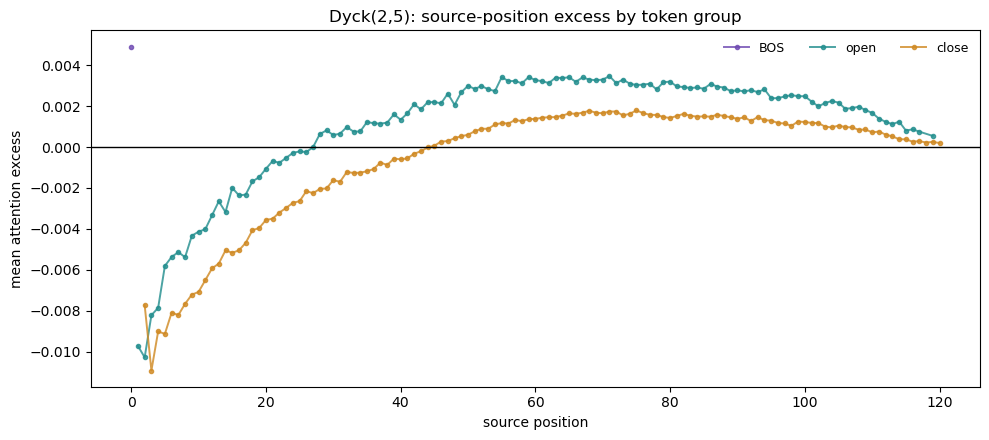

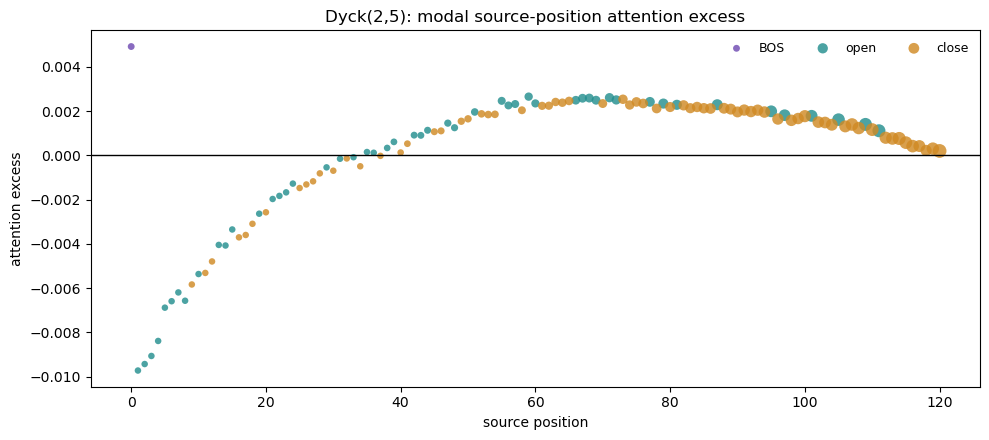

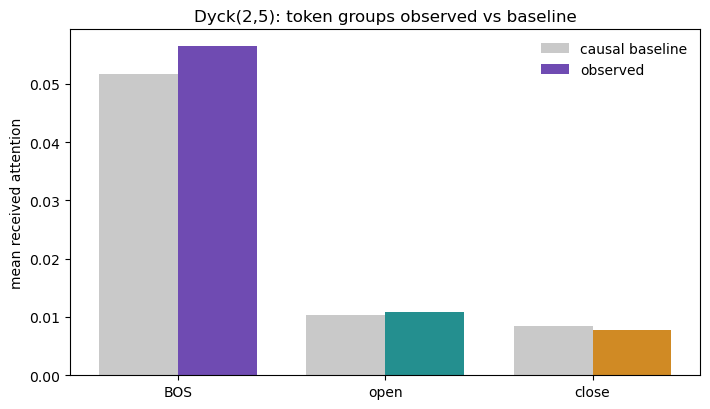

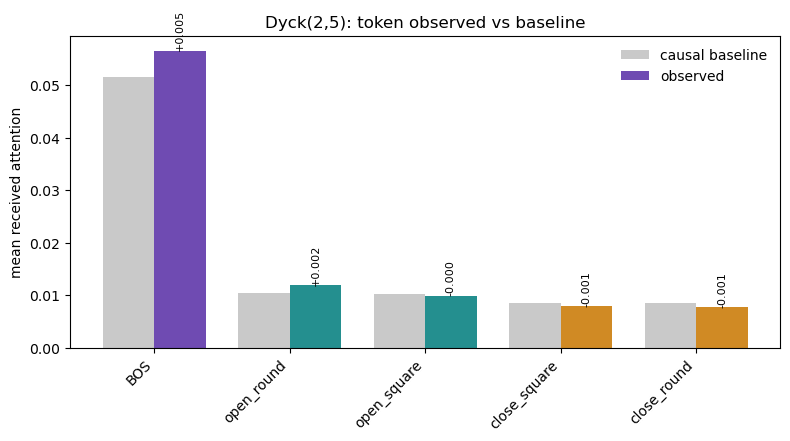

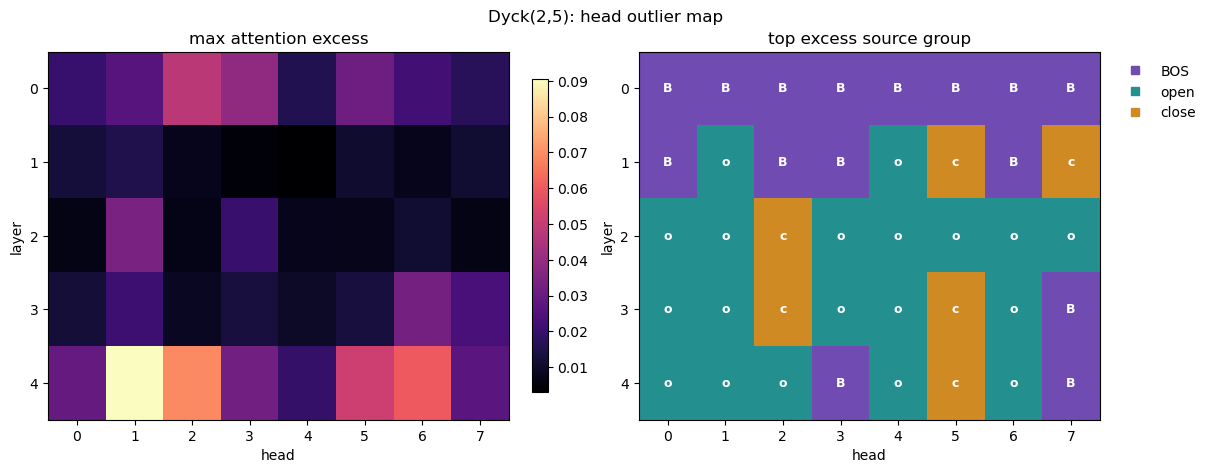

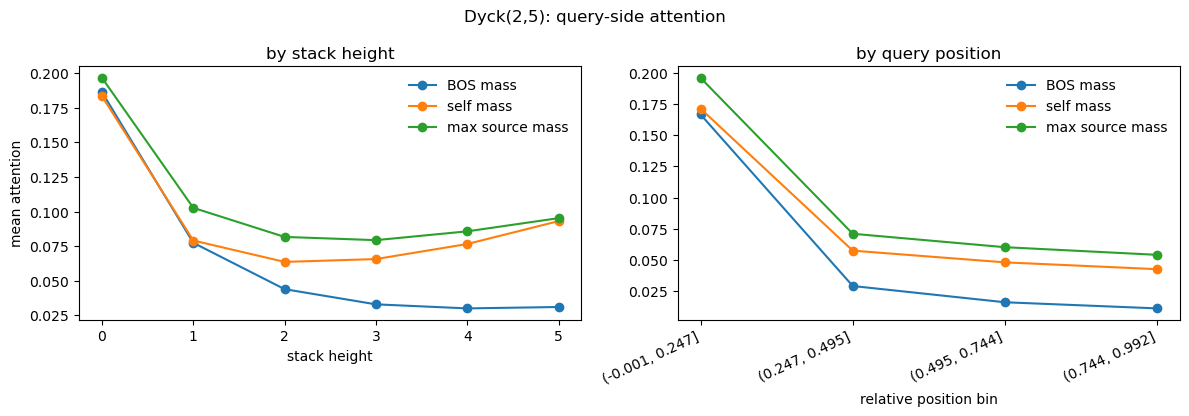

extra attention figures saved under /home/hp_twist_shan/Research/Hidden State Evaluation/results/dyck25_cfg_next_token_len_80_120/attention/transformer_seed20025_n96/figures


In [31]:
ATTENTION_GROUP_COLORS = {
    'BOS': '#6f4bb2',
    'open': '#248f8f',
    'close': '#d08a24',
    'noise': '#777777',
    'EOS': '#b54b5a',
    'other': '#aaaaaa',
}


def infer_attention_group(name):
    name = str(name)
    if name == 'BOS':
        return 'BOS'
    if name == 'EOS':
        return 'EOS'
    if name.startswith('open_'):
        return 'open'
    if name.startswith('close_'):
        return 'close'
    if name.startswith('noise_'):
        return 'noise'
    return 'other'


def plot_source_excess_by_position_grouped(source_df, figures_root, title):
    data = source_df.copy()
    if 'token_group' not in data:
        data['token_group'] = data['token_name'].map(infer_attention_group)
    grouped = data.groupby(['source_position', 'token_group'], as_index=False).agg(
        n=('excess_mass', 'size'),
        observed=('observed_mass', 'mean'),
        baseline=('uniform_baseline_mass', 'mean'),
        excess=('excess_mass', 'mean'),
        sink_ratio=('sink_ratio', 'mean'),
    )
    fig, ax = plt.subplots(figsize=(10, 4.5))
    for group, sub in grouped.groupby('token_group', sort=False):
        sub = sub.sort_values('source_position')
        ax.plot(
            sub['source_position'],
            sub['excess'],
            marker='o',
            markersize=3,
            linewidth=1.4,
            alpha=0.82,
            color=ATTENTION_GROUP_COLORS.get(group, ATTENTION_GROUP_COLORS['other']),
            label=group,
        )
    ax.axhline(0, color='black', linewidth=1)
    ax.set_xlabel('source position')
    ax.set_ylabel('mean attention excess')
    ax.set_title(title)
    ax.legend(ncol=4, fontsize=9, frameon=False)
    fig.tight_layout()
    fig.savefig(figures_root / 'source_excess_by_position_grouped.png', dpi=180)
    plt.show()
    plt.close(fig)
    grouped.to_csv(ATTENTION_ROOT / 'source_position_group_summary.csv', index=False)
    return grouped


def plot_source_excess_by_position_colored(position_df, figures_root, title):
    data = position_df.copy()
    if 'token_group' not in data:
        data['token_group'] = data['token_name'].map(infer_attention_group)
    fig, ax = plt.subplots(figsize=(10, 4.5))
    for group, sub in data.groupby('token_group', sort=False):
        ax.scatter(
            sub['source_position'],
            sub['excess'],
            s=22 + 80 * np.clip(sub['sink_ratio'] - 1.0, 0, 3) / 3,
            color=ATTENTION_GROUP_COLORS.get(group, ATTENTION_GROUP_COLORS['other']),
            alpha=0.82,
            label=group,
            edgecolors='none',
        )
    ax.axhline(0, color='black', linewidth=1)
    ax.set_xlabel('source position')
    ax.set_ylabel('attention excess')
    ax.set_title(title)
    ax.legend(ncol=4, fontsize=9, frameon=False)
    fig.tight_layout()
    fig.savefig(figures_root / 'source_excess_by_position_colored.png', dpi=180)
    plt.show()
    plt.close(fig)


def plot_token_group_observed_vs_baseline(group_df, figures_root, title):
    data = group_df.sort_values('excess', ascending=False).copy()
    x = np.arange(len(data))
    width = 0.38
    fig, ax = plt.subplots(figsize=(7.2, 4.2))
    ax.bar(x - width / 2, data['baseline'], width, label='causal baseline', color='#c9c9c9')
    ax.bar(
        x + width / 2,
        data['observed'],
        width,
        label='observed',
        color=[ATTENTION_GROUP_COLORS.get(g, ATTENTION_GROUP_COLORS['other']) for g in data['token_group']],
    )
    ax.set_xticks(x)
    ax.set_xticklabels(data['token_group'])
    ax.set_ylabel('mean received attention')
    ax.set_title(title)
    ax.legend(frameon=False)
    fig.tight_layout()
    fig.savefig(figures_root / 'token_group_observed_vs_baseline.png', dpi=180)
    plt.show()
    plt.close(fig)


def plot_token_observed_vs_baseline(token_df, figures_root, title, max_tokens=18):
    data = token_df.copy()
    if 'token_group' not in data:
        data['token_group'] = data['token_name'].map(infer_attention_group)
    data = data.sort_values('excess', ascending=False).head(max_tokens)
    x = np.arange(len(data))
    width = 0.38
    fig, ax = plt.subplots(figsize=(max(8, len(data) * 0.55), 4.5))
    ax.bar(x - width / 2, data['baseline'], width, label='causal baseline', color='#c9c9c9')
    bars = ax.bar(
        x + width / 2,
        data['observed'],
        width,
        label='observed',
        color=[ATTENTION_GROUP_COLORS.get(g, ATTENTION_GROUP_COLORS['other']) for g in data['token_group']],
    )
    for bar, excess in zip(bars, data['excess']):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f'{excess:+.3f}',
            ha='center',
            va='bottom',
            fontsize=8,
            rotation=90,
        )
    ax.set_xticks(x)
    ax.set_xticklabels(data['token_name'], rotation=45, ha='right')
    ax.set_ylabel('mean received attention')
    ax.set_title(title)
    ax.legend(frameon=False)
    fig.tight_layout()
    fig.savefig(figures_root / 'token_observed_vs_baseline.png', dpi=180)
    plt.show()
    plt.close(fig)


def plot_head_excess_and_top_group(head_df, figures_root, title):
    data = head_df.copy()
    if 'excess_top_group' not in data:
        data['excess_top_group'] = data['excess_top_token'].map(infer_attention_group)
    heat = data.pivot(index='layer', columns='head', values='max_excess_mean').sort_index()
    group = data.pivot(index='layer', columns='head', values='excess_top_group').loc[heat.index, heat.columns]
    group_order = ['BOS', 'open', 'close', 'noise', 'EOS', 'other']
    group_to_idx = {name: idx for idx, name in enumerate(group_order)}
    group_idx = group.map(lambda x: group_to_idx.get(x, group_to_idx['other']))
    cmap = plt.matplotlib.colors.ListedColormap([ATTENTION_GROUP_COLORS[g] for g in group_order])

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.4), constrained_layout=True)
    im0 = axes[0].imshow(heat.to_numpy(), aspect='auto', cmap='magma')
    axes[0].set_title('max attention excess')
    axes[0].set_xlabel('head')
    axes[0].set_ylabel('layer')
    axes[0].set_xticks(range(heat.shape[1]))
    axes[0].set_xticklabels(heat.columns)
    axes[0].set_yticks(range(heat.shape[0]))
    axes[0].set_yticklabels(heat.index)
    fig.colorbar(im0, ax=axes[0], shrink=0.85)

    axes[1].imshow(group_idx.to_numpy(), aspect='auto', cmap=cmap, vmin=-0.5, vmax=len(group_order) - 0.5)
    axes[1].set_title('top excess source group')
    axes[1].set_xlabel('head')
    axes[1].set_ylabel('layer')
    axes[1].set_xticks(range(group.shape[1]))
    axes[1].set_xticklabels(group.columns)
    axes[1].set_yticks(range(group.shape[0]))
    axes[1].set_yticklabels(group.index)
    for i in range(group.shape[0]):
        for j in range(group.shape[1]):
            label = str(group.iat[i, j])
            axes[1].text(j, i, label[:1], ha='center', va='center', color='white', fontsize=9, fontweight='bold')
    handles = [
        plt.Line2D([0], [0], marker='s', linestyle='', color=ATTENTION_GROUP_COLORS[g], label=g)
        for g in group_order
        if g in set(group.to_numpy().ravel())
    ]
    axes[1].legend(handles=handles, loc='upper left', bbox_to_anchor=(1.02, 1.0), frameon=False)
    fig.suptitle(title, y=1.04)
    fig.savefig(figures_root / 'head_excess_and_top_group.png', dpi=180, bbox_inches='tight')
    plt.show()
    plt.close(fig)


def plot_query_bos_self_by_height_and_position(query_height_df, query_position_df, figures_root):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
    axes[0].plot(query_height_df['height'], query_height_df['bos_mass'], marker='o', label='BOS mass')
    axes[0].plot(query_height_df['height'], query_height_df['self_mass'], marker='o', label='self mass')
    axes[0].plot(query_height_df['height'], query_height_df['max_mass'], marker='o', label='max source mass')
    axes[0].set_xlabel('stack height')
    axes[0].set_ylabel('mean attention')
    axes[0].set_title('by stack height')
    axes[0].legend(frameon=False)

    x = np.arange(len(query_position_df))
    axes[1].plot(x, query_position_df['bos_mass'], marker='o', label='BOS mass')
    axes[1].plot(x, query_position_df['self_mass'], marker='o', label='self mass')
    axes[1].plot(x, query_position_df['max_mass'], marker='o', label='max source mass')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(query_position_df['pos_bin'].astype(str), rotation=25, ha='right')
    axes[1].set_xlabel('relative position bin')
    axes[1].set_title('by query position')
    axes[1].legend(frameon=False)
    fig.suptitle('Dyck(2,5): query-side attention')
    fig.tight_layout()
    fig.savefig(figures_root / 'query_bos_self_by_height_and_position.png', dpi=180)
    plt.show()
    plt.close(fig)

attention_source_rows_df = pd.read_csv(ATTENTION_ROOT / 'source_attention_rows.csv')
attention_token_summary_for_groups_df = attention_token_summary_df.copy()
attention_token_summary_for_groups_df['token_group'] = attention_token_summary_for_groups_df['token_name'].map(infer_attention_group)
attention_group_summary_df = attention_token_summary_for_groups_df.groupby('token_group', as_index=False).agg(
    n=('n', 'sum'),
    observed=('observed', 'mean'),
    baseline=('baseline', 'mean'),
    excess=('excess', 'mean'),
    sink_ratio=('sink_ratio', 'mean'),
)
attention_group_summary_df.to_csv(ATTENTION_ROOT / 'token_group_source_summary.csv', index=False)

attention_source_position_group_df = plot_source_excess_by_position_grouped(
    attention_source_rows_df,
    ATTENTION_FIGURES_ROOT,
    'Dyck(2,5): source-position excess by token group',
)
plot_source_excess_by_position_colored(
    attention_position_summary_df,
    ATTENTION_FIGURES_ROOT,
    'Dyck(2,5): modal source-position attention excess',
)
plot_token_group_observed_vs_baseline(
    attention_group_summary_df,
    ATTENTION_FIGURES_ROOT,
    'Dyck(2,5): token groups observed vs baseline',
)
plot_token_observed_vs_baseline(
    attention_token_summary_df,
    ATTENTION_FIGURES_ROOT,
    'Dyck(2,5): token observed vs baseline',
)
plot_head_excess_and_top_group(
    attention_head_summary_df,
    ATTENTION_FIGURES_ROOT,
    'Dyck(2,5): head outlier map',
)
plot_query_bos_self_by_height_and_position(
    attention_query_height_summary_df,
    attention_query_position_bin_summary_df,
    ATTENTION_FIGURES_ROOT,
)

print(f'extra attention figures saved under {ATTENTION_FIGURES_ROOT}')

Dyck(2,5) Transformer 确实有 outlier/sink 现象，但不是简单的 BOS-only sink。BOS 在 position 0 有稳定的正 excess，说明它是低层和序列前段的起点锚点；不过 source-position 曲线和 token-level bar 更重要地显示，中后段 attention 会明显转向 bracket 结构 token，尤其是 `open_*`，它们比 close token 更像 stack/depth 的结构锚点。head map 进一步把这个分工拆开：layer 0 多数 head 的 top sink 是 BOS，而 layer 2-4 大量 head 转向 open/close，其中最后一层几个 head 的 max excess 最大，说明高层在做更结构化的 Dyck 状态聚合。query-side 图也支持同一结论：height=0 和序列前段时 BOS mass 很高；随着 stack 变深、位置后移，BOS mass 快速下降，self/max-source attention 占比上升。重点 takeaway 是：模型并不是靠一个 BOS token 记住任务，而是先用 BOS 做全局锚定，再在高层把 opening bracket 当作主要结构锚点来维护 Dyck stack state。